# 24/07/07 - Estudos de redes com duas camadas e de 4 a 32 neurônios e peso na perda da condição inicial e dados



## Resumo

- Função de perda: RMSE
- Parânmetros do modelo: k--0.01__phi--0.2__ksi--0.0__cb--0.15__Cn_max--0.55__lambd_nb--1.8__mi_n--0.2__lambd_bn--0.1__y_n--0.1__t_lower--0.0__t_upper--10.0
- Funções de  ativação: 
    - LeakyReLU
    - Sigmoid
    - Elu 
    - Tanh
    - ReLU
    - SiLU

- Tamanhos de batelada e épocas:
    - (10000, 500)
    - (5000, 1000)

- Arquivo de checkpoint: 1719945754

- Peso da perda de cond. inicial: 10

- Peso da perda de dados: 10

## Análise de erro vs speedup

In [ ]:
import glob
import pickle as pk
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tools import generate_model, train_data

In [11]:
result_list = glob.glob("edo_pinn_sim/*")

print("numero de arquiteturas testadas: {}".format(len(result_list)))

numero de arquiteturas testadas: 17


In [11]:
results_dict = {}

error_list = []

speed_list = []

for file in result_list:
    i = len(error_list)
    if file.split(".")[-1] == "pkl":
        with open(file, "rb") as f:
            aux_dict = pk.load(f)

        results_dict[i] = {
            "rmse": aux_dict["rmse"],
            "max_ae": aux_dict["max_ae"],
            "mean_speed_up": aux_dict["mean_speed_up"],
            "std_speed_up": aux_dict["std_speed_up"],
            "arch_name": file.split("/")[-1].split(".")[0],
            "file": file,
        }

        results_dict[i]["arch_name"] = file.split("/")[-1].split(".")[0]

        error_list.append(results_dict[i]["rmse"] + results_dict[i]["max_ae"])
        speed_list.append(
            results_dict[i]["mean_speed_up"] - results_dict[i]["std_speed_up"]
        )

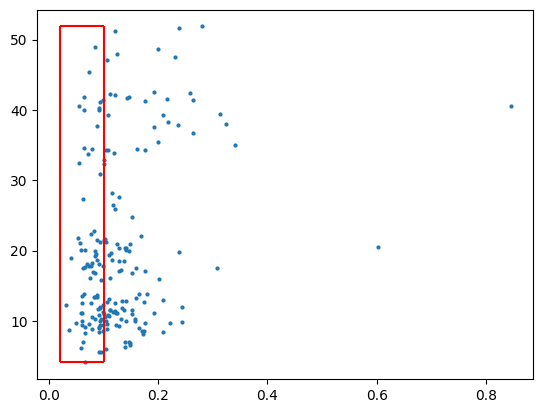

In [12]:
x_lim = (0.02, 0.1)
plt.scatter(error_list, speed_list, s=4)
plt.hlines(max(speed_list), x_lim[0], x_lim[1], color="r")
plt.hlines(min(speed_list), x_lim[0], x_lim[1], color="r")
plt.vlines(x_lim[1], min(speed_list), max(speed_list), color="r")
plt.vlines(x_lim[0], min(speed_list), max(speed_list), color="r")
plt.show()

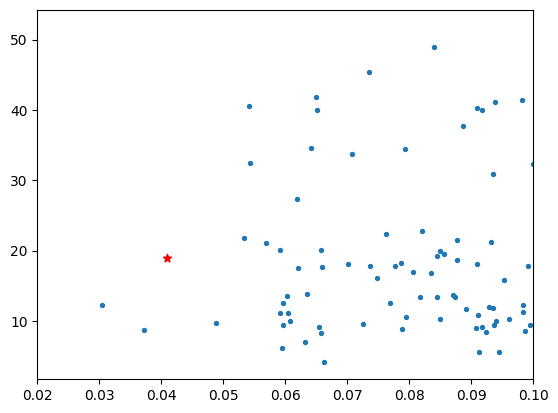

Arquitetura escolhida: epochs_1400__batch_50000__arch_LeakyReLU--4__Tanh--16__
Erro absoluto médio 0.0066176103
Erro absoluto máximo 0.034312367
Speed Up: 19.57014557295725 +/-0.6665235434564675


In [13]:
choice = np.intersect1d(
    np.argwhere(np.array(speed_list) > 15), np.argwhere(np.array(error_list) < 0.05)
)[0]

plt.scatter(error_list, speed_list, s=8)
plt.scatter(error_list[choice], speed_list[choice], c="r", marker="*")
plt.xlim(x_lim[0], x_lim[1])
plt.ylim()
plt.show()

arch_str = results_dict[choice]["arch_name"]

print("Arquitetura escolhida: " + arch_str)
print("Erro absoluto médio", results_dict[choice]["rmse"])
print("Erro absoluto máximo", results_dict[choice]["max_ae"])
print(
    "Speed Up: {} +/-{}".format(
        results_dict[choice]["mean_speed_up"], results_dict[choice]["std_speed_up"]
    )
)

In [15]:
with open("learning_curves/C_pde_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_pde_loss_it = pk.load(f)

with open("learning_curves/C_data_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_data_loss_it = pk.load(f)

with open("learning_curves/C_initial_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_initial_loss_it = pk.load(f)

results_dict[choice]

with open(results_dict[choice]["file"], "rb") as f:
    aux_dict = pk.load(f)
    Cl_pinn_lin = aux_dict["Cl_pinn"].numpy()
    Cp_pinn_lin = aux_dict["Cp_pinn"].numpy()

size_t = int(len(Cl_pinn_lin) ** 0.5)

struct_name = "k--0.01__phi--0.2__ksi--0.0__cb--0.15__Cn_max--0.55__lambd_nb--1.8__mi_n--0.2__lambd_bn--0.1__y_n--0.1__t_lower--0.0__t_upper--10.0"


with open("edo_fdm_sim/Cp__" + struct_name + ".pkl", "rb") as f:
    Cp = pk.load(f)

with open("edo_fdm_sim/Cl__" + struct_name + ".pkl", "rb") as f:
    Cl = pk.load(f)

Cl_pinn_np = Cl_pinn_lin.reshape(size_t, size_t)
Cp_pinn_np = Cp_pinn_lin.reshape(size_t, size_t)

lmb_var = 0.4

lmb_list = np.linspace(
    1.8 * (1 - lmb_var), 1.8 * (1 + lmb_var), num=size_t, endpoint=True
)

t_np = np.linspace(0, 10, num=size_t, endpoint=True)

tt, ll = np.meshgrid(t_np, lmb_list)

In [16]:
data_input_np = np.array([Cl.flatten(), Cp.flatten()]).T

if torch.cuda.is_available():
    device = torch.device("cuda")
    t = (
        torch.tensor(tt, dtype=torch.float32, requires_grad=True)
        .reshape(-1, 1)
        .to(device)
    )
    lambd_nb = (
        torch.tensor(ll, dtype=torch.float32, requires_grad=True)
        .reshape(-1, 1)
        .to(device)
    )
    data_input = torch.tensor(data_input_np, dtype=torch.float32).to(device)

else:
    device = torch.device("cpu")
    t = torch.tensor(tt, dtype=torch.float32, requires_grad=True).reshape(-1, 1)
    lambd_nb = torch.tensor(ll, dtype=torch.float32, requires_grad=True).reshape(-1, 1)
    data_input = torch.tensor(data_input_np, dtype=torch.float32)

n_epochs = int(arch_str.split("__")[0].split("_")[-1])
batch_size = int(arch_str.split("__")[1].split("_")[-1])
model = generate_model(arch_str.split("arch_")[-1]).to(device)

model, nn_loss = train_data(
    n_epochs=n_epochs,
    batch_size=batch_size,
    decay_rate=0.99,
    model=model,
    lambd_nb=lambd_nb,
    device=device,
    data_input=data_input,
    t=t,
)

mesh = torch.cat([t, lambd_nb], dim=1)
with torch.no_grad():
    Cl_pinn_data, Cp_pinn_data = model(mesh).split(1, dim=1)

Cl_pinn_data_np = Cl_pinn_data.reshape(size_t, size_t).cpu().numpy()
Cp_pinn_data_np = Cp_pinn_data.reshape(size_t, size_t).cpu().numpy()

Finished epoch 0, latest loss 0.16844630241394043


KeyboardInterrupt: 

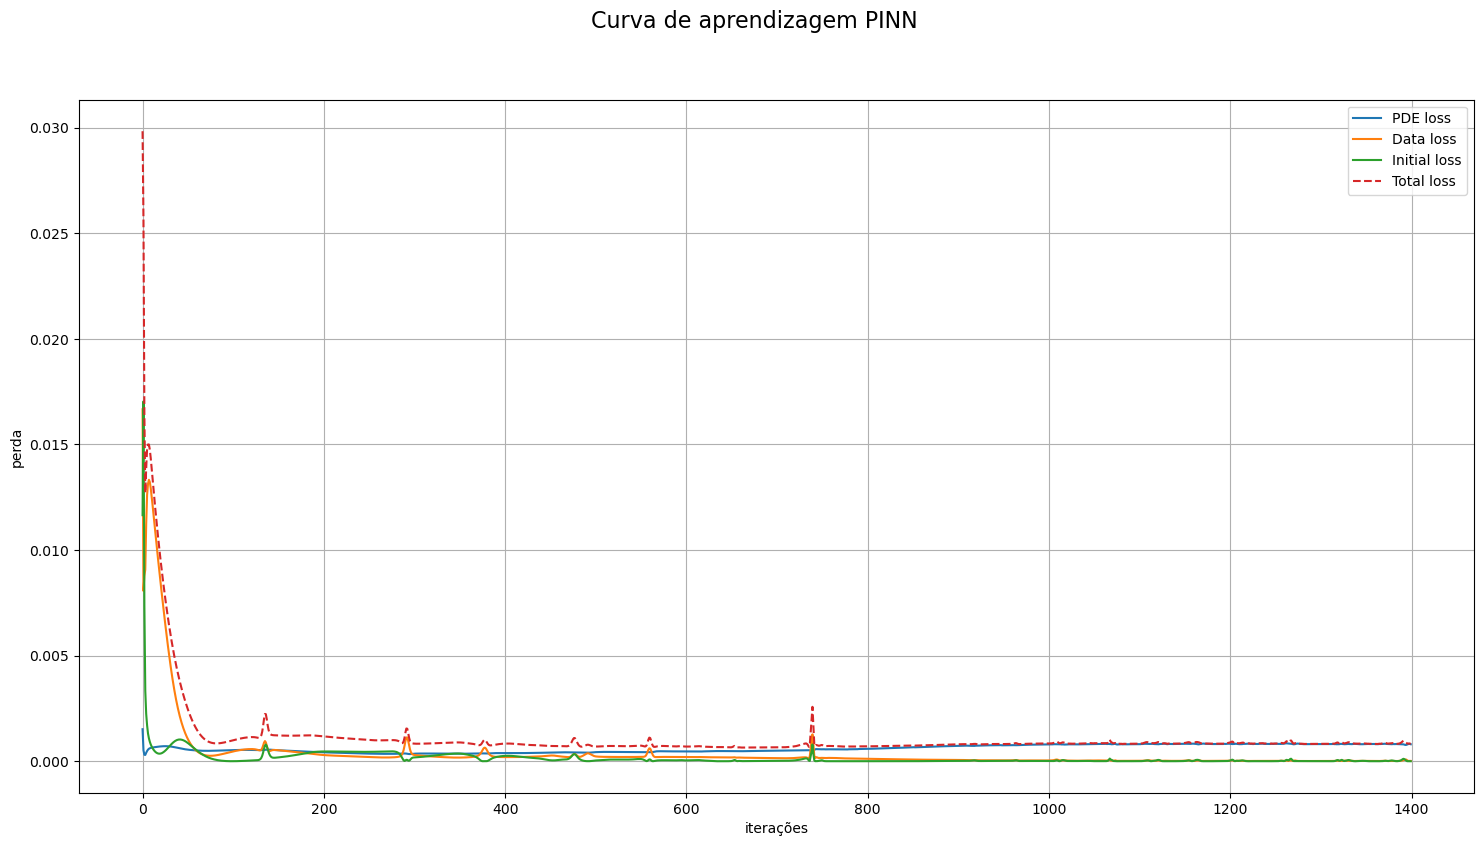

: 

In [16]:
fig = plt.figure(figsize=[18, 9])

fig.suptitle("Curva de aprendizagem PINN", fontsize=16)

# Plotango 3D
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel("iterações")
ax.set_ylabel("perda")
ax.plot(
    range(len(C_pde_loss_it)),
    C_pde_loss_it,
    label="PDE loss",
)
ax.plot(
    range(len(C_data_loss_it)),
    C_data_loss_it,
    label="Data loss",
)
ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it,
    label="Initial loss",
)
ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it + C_data_loss_it + C_pde_loss_it,
    "--",
    label="Total loss",
)

# ax.set_yscale("log")
ax.grid()
ax.legend()

plt.show()

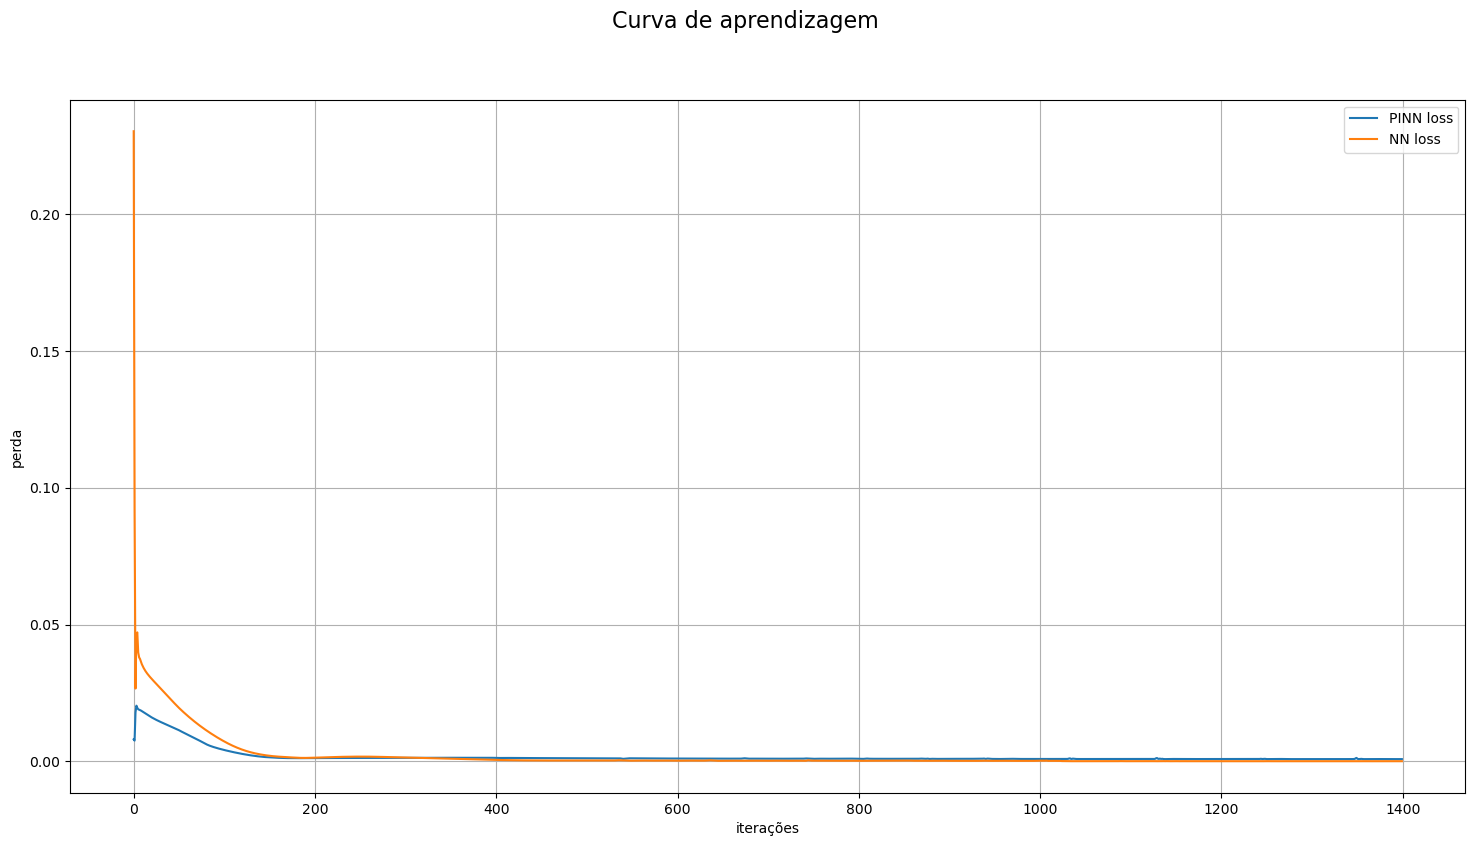

In [10]:
fig = plt.figure(figsize=[18, 9])

fig.suptitle("Curva de aprendizagem", fontsize=16)

# Plotango 3D
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel("iterações")
ax.set_ylabel("perda")

ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it + C_data_loss_it + C_pde_loss_it,
    label="PINN loss",
)
ax.plot(
    range(len(C_initial_loss_it)),
    nn_loss.cpu().numpy(),
    label="NN loss",
)
# ax.set_yscale("log")
ax.grid()
ax.legend()

plt.show()

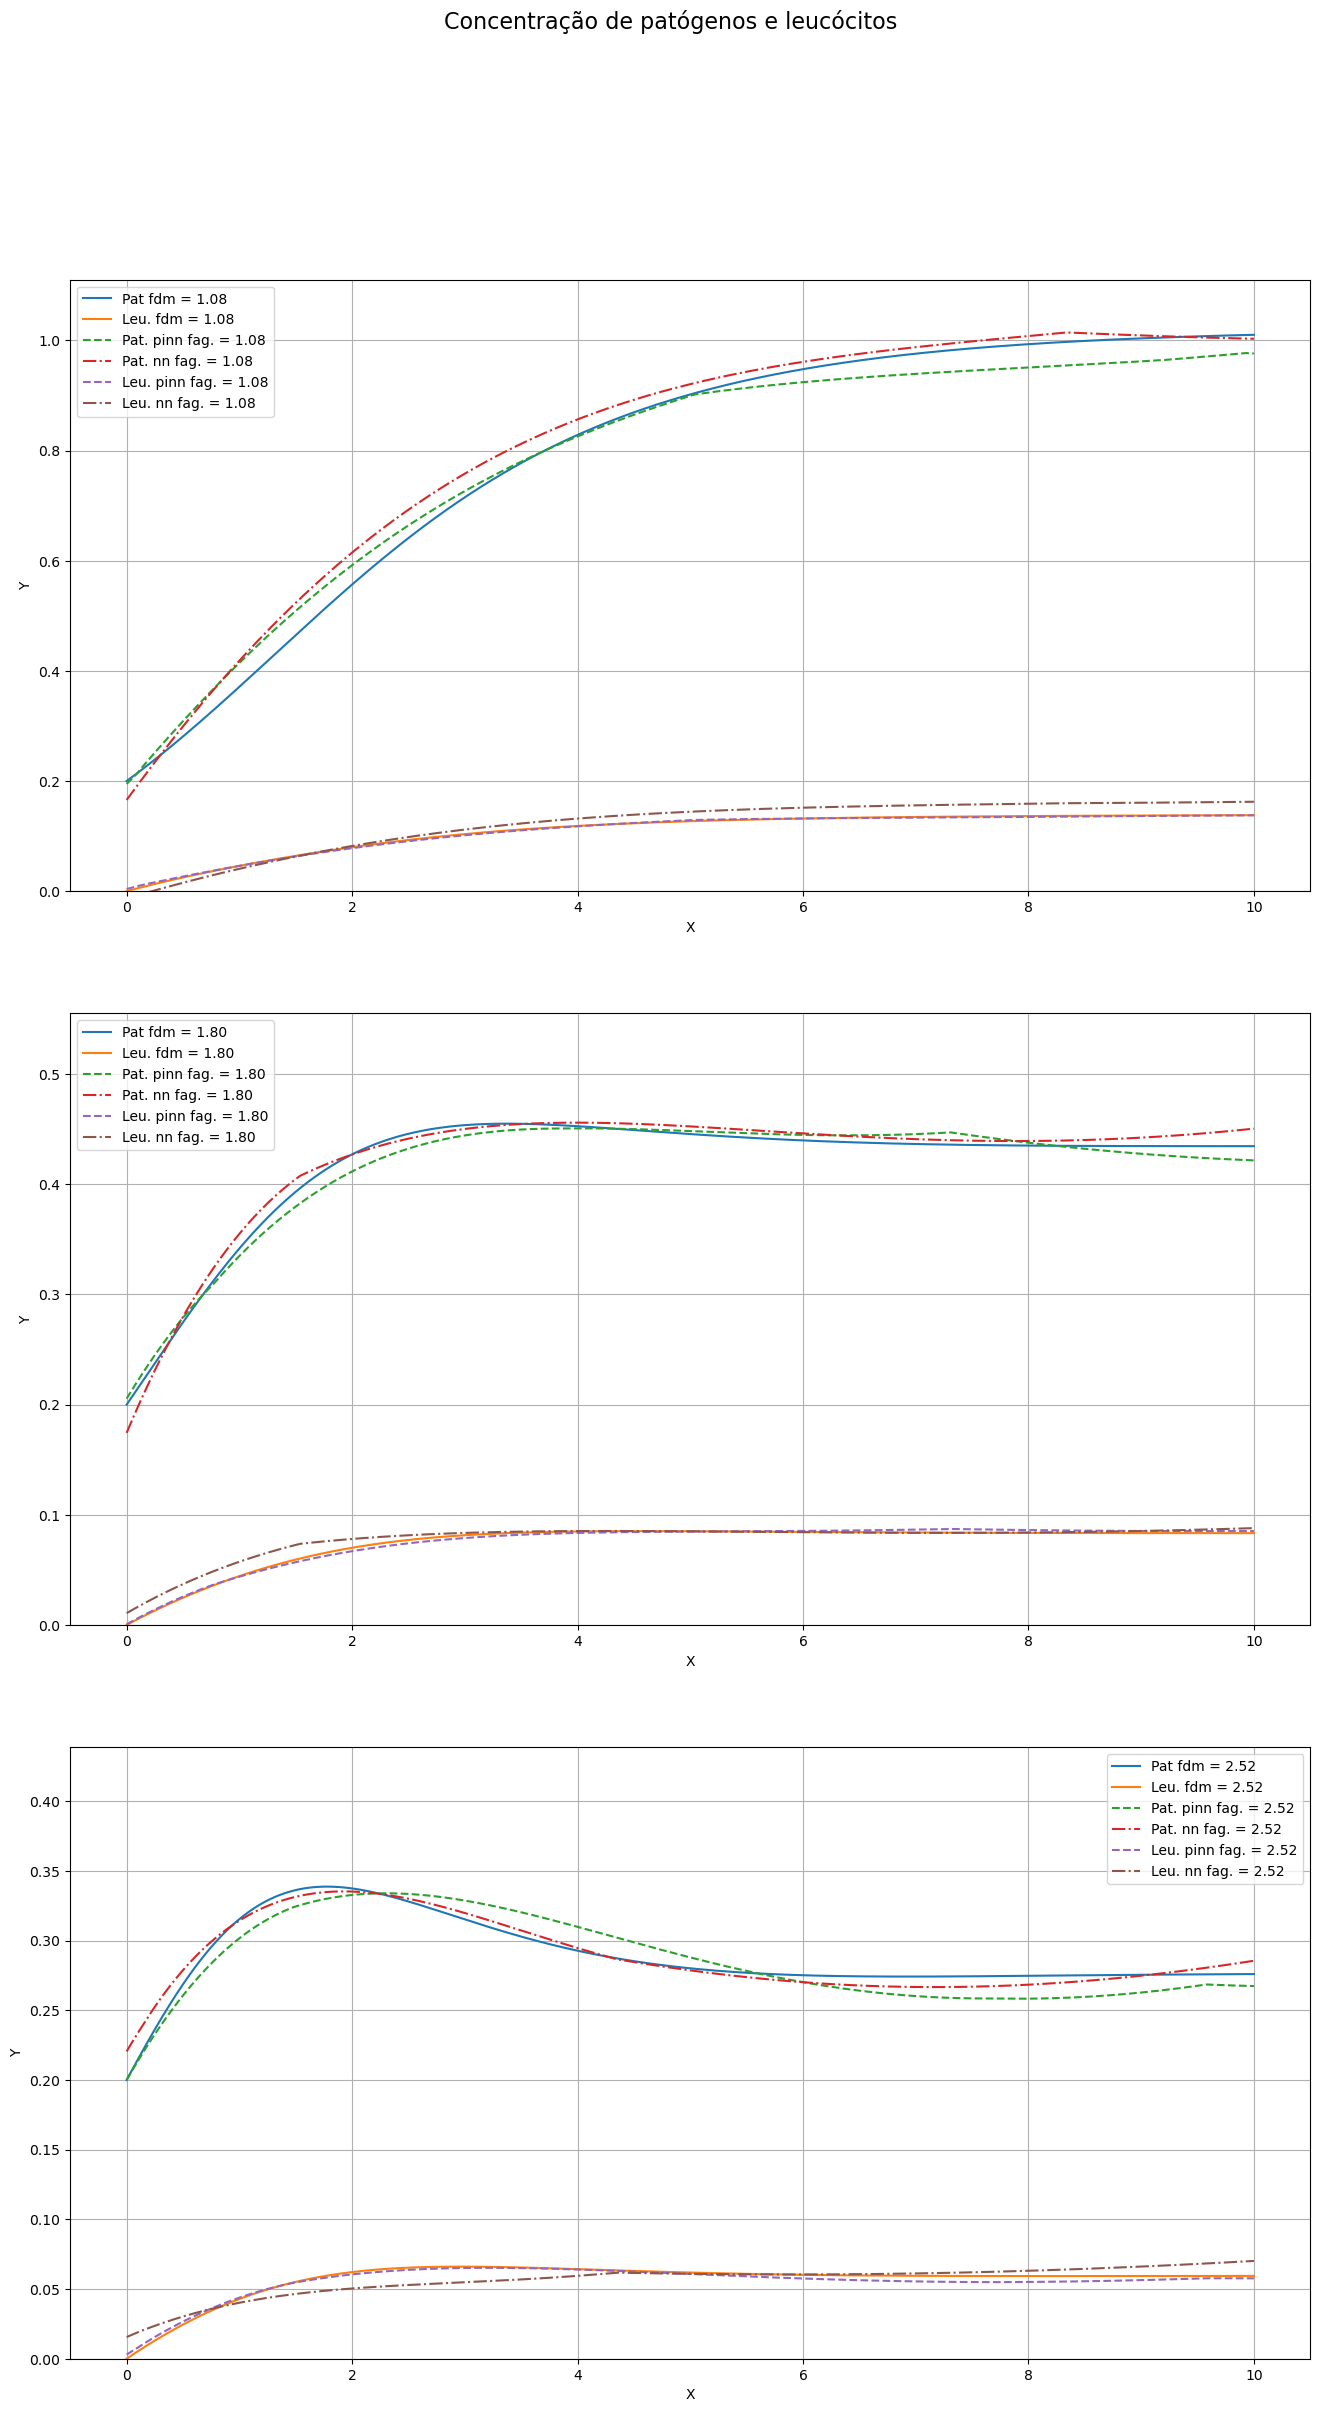

In [11]:
fig = plt.figure(figsize=[16, 27])

fig.suptitle("Concentração de patógenos e leucócitos", fontsize=16)


vmin = 0

cp_real_1 = Cp[0, :]
cl_real_1 = Cl[0, :]
cp_pinn_1 = Cp_pinn_np[0, :]
cl_pinn_1 = Cl_pinn_np[0, :]
cl_pinn_data_1 = Cl_pinn_data_np[0, :]
cp_pinn_data_1 = Cp_pinn_data_np[0, :]
fag_1 = lmb_list[0]

cp_real_2 = Cp[500, :]
cl_real_2 = Cl[500, :]
cp_pinn_2 = Cp_pinn_np[500, :]
cl_pinn_2 = Cl_pinn_np[500, :]
cl_pinn_data_2 = Cl_pinn_data_np[500, :]
cp_pinn_data_2 = Cp_pinn_data_np[500, :]
fag_2 = lmb_list[500]

cp_real_3 = Cp[1000, :]
cl_real_3 = Cl[1000, :]
cp_pinn_3 = Cp_pinn_np[1000, :]
cl_pinn_3 = Cl_pinn_np[1000, :]
cl_pinn_data_3 = Cl_pinn_data_np[1000, :]
cp_pinn_data_3 = Cp_pinn_data_np[1000, :]
fag_3 = lmb_list[1000]

# Plotango 3D
ax = fig.add_subplot(3, 1, 1)

ax.plot(t_np, cp_real_1, label="Pat fdm = {:.2f}".format(fag_1))
ax.plot(t_np, cl_real_1, label="Leu. fdm = {:.2f}".format(fag_1))
ax.plot(t_np, cp_pinn_1, "--", label="Pat. pinn fag. = {:.2f}".format(fag_1))
ax.plot(t_np, cp_pinn_data_1, "-.", label="Pat. nn fag. = {:.2f}".format(fag_1))
ax.plot(t_np, cl_pinn_1, "--", label="Leu. pinn fag. = {:.2f}".format(fag_1))
ax.plot(t_np, cl_pinn_data_1, "-.", label="Leu. nn fag. = {:.2f}".format(fag_1))
ax.set_xlabel("X")
ax.set_ylabel("Y")

vmax = np.max(
    [
        np.max(cp_real_1),
        np.max(cl_real_1),
        np.max(cp_pinn_1),
        np.max(cl_pinn_1),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

ax = fig.add_subplot(3, 1, 2)

ax.plot(t_np, cp_real_2, label="Pat fdm = {:.2f}".format(fag_2))
ax.plot(t_np, cl_real_2, label="Leu. fdm = {:.2f}".format(fag_2))
ax.plot(t_np, cp_pinn_2, "--", label="Pat. pinn fag. = {:.2f}".format(fag_2))
ax.plot(t_np, cp_pinn_data_2, "-.", label="Pat. nn fag. = {:.2f}".format(fag_2))
ax.plot(t_np, cl_pinn_2, "--", label="Leu. pinn fag. = {:.2f}".format(fag_2))
ax.plot(t_np, cl_pinn_data_2, "-.", label="Leu. nn fag. = {:.2f}".format(fag_2))
ax.set_xlabel("X")
ax.set_ylabel("Y")
vmax = np.max(
    [
        np.max(cp_real_2),
        np.max(cl_real_2),
        np.max(cp_pinn_2),
        np.max(cl_pinn_2),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

ax = fig.add_subplot(3, 1, 3)

ax.plot(t_np, cp_real_3, label="Pat fdm = {:.2f}".format(fag_3))
ax.plot(t_np, cl_real_3, label="Leu. fdm = {:.2f}".format(fag_3))
ax.plot(t_np, cp_pinn_3, "--", label="Pat. pinn fag. = {:.2f}".format(fag_3))
ax.plot(t_np, cp_pinn_data_3, "-.", label="Pat. nn fag. = {:.2f}".format(fag_3))
ax.plot(t_np, cl_pinn_3, "--", label="Leu. pinn fag. = {:.2f}".format(fag_3))
ax.plot(t_np, cl_pinn_data_3, "-.", label="Leu. nn fag. = {:.2f}".format(fag_3))
ax.set_xlabel("X")
ax.set_ylabel("Y")
vmax = np.max(
    [
        np.max(cp_real_3),
        np.max(cl_real_3),
        np.max(cp_pinn_3),
        np.max(cl_pinn_3),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

plt.show()

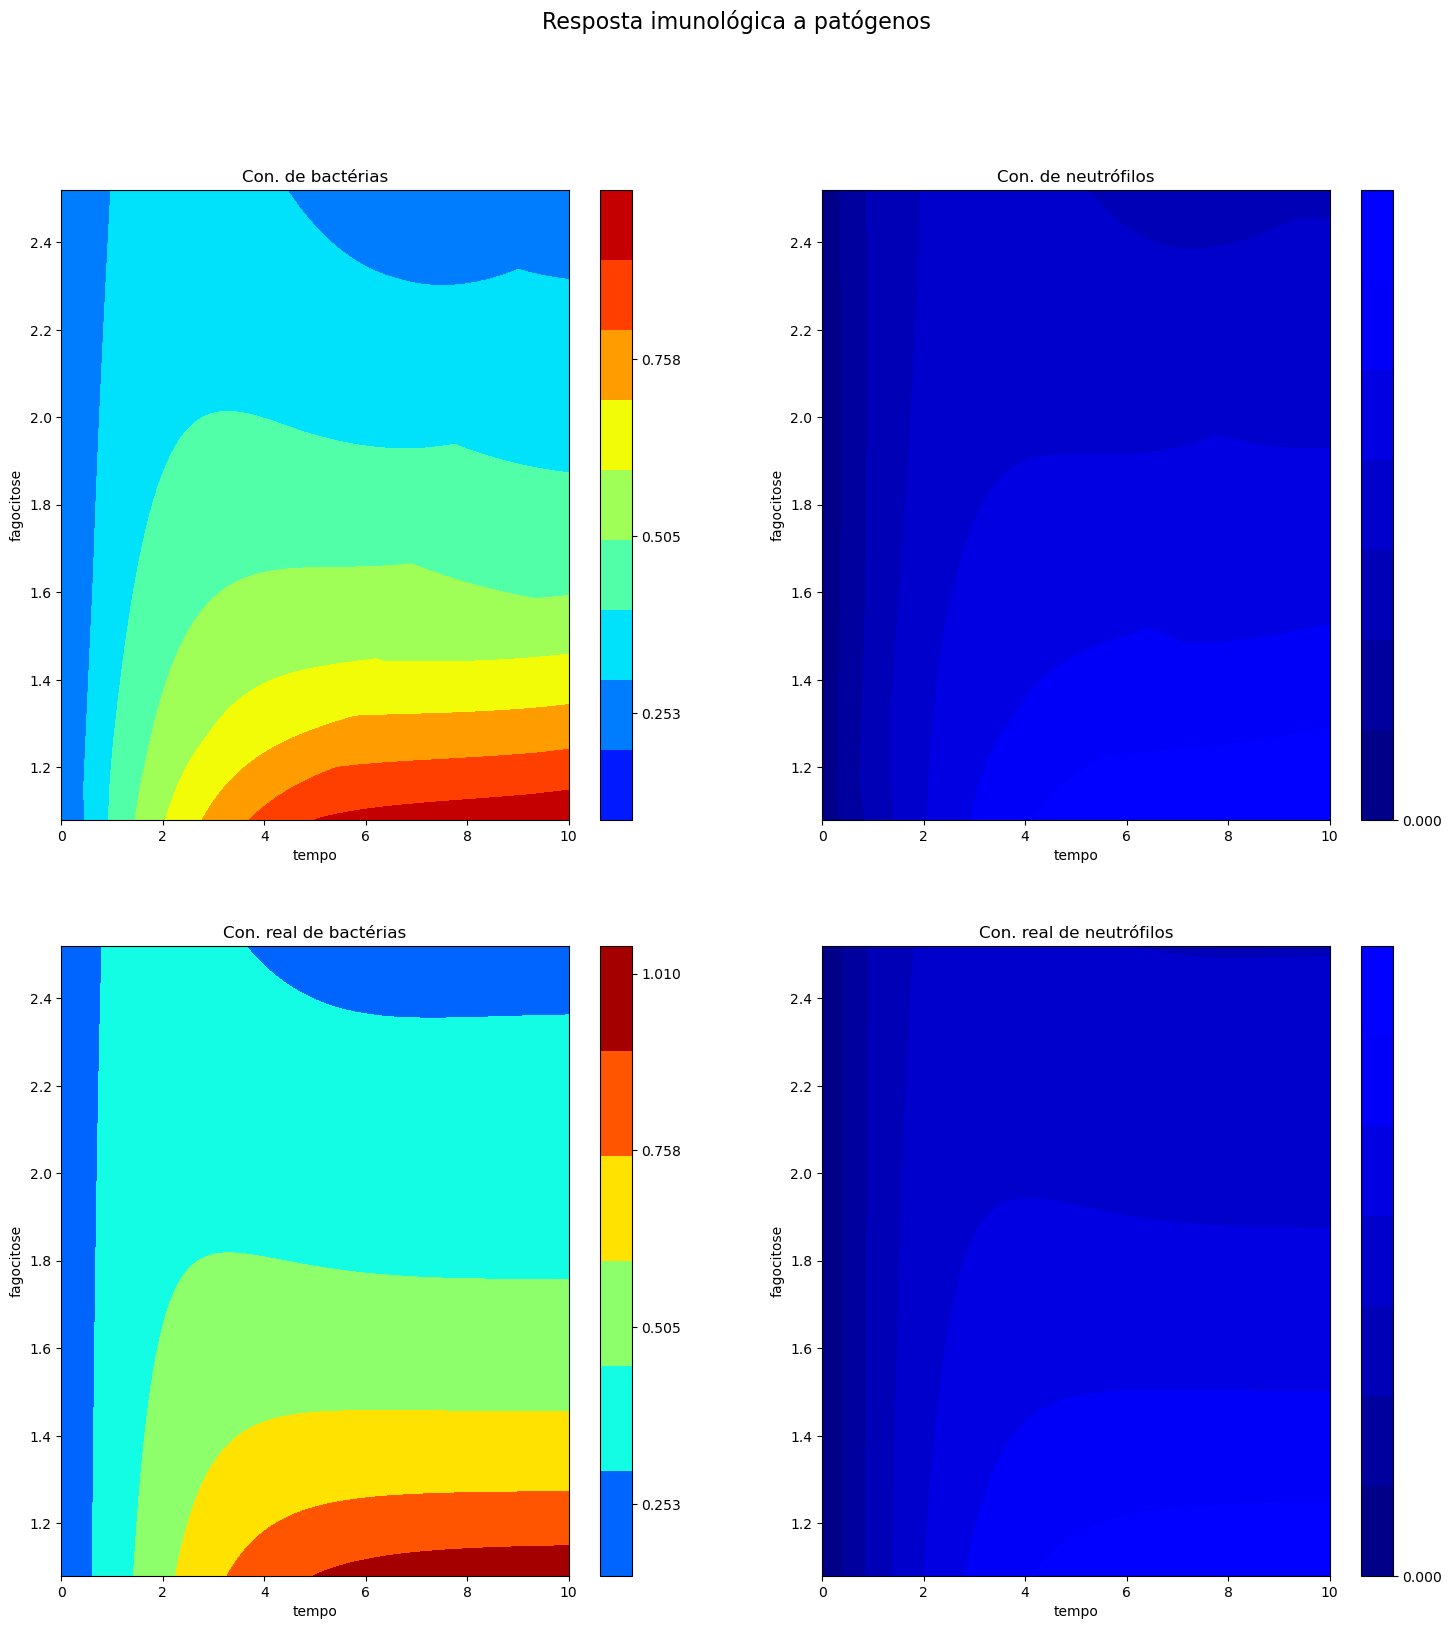

Speed Up: 48.9284579561603 +/-8.363353275197165


In [12]:
fig = plt.figure(figsize=[18, 18])

fig.suptitle("Resposta imunológica a patógenos", fontsize=16)

vmin = 0
vmax = np.max(
    [
        np.max(Cl_pinn_lin),
        np.max(Cp_pinn_lin),
        np.max(Cp),
        np.max(Cl),
    ]
)

# Plotango 3D
ax = fig.add_subplot(2, 2, 1)

contour = ax.contourf(
    tt,
    ll,
    Cp_pinn_np,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Con. de bactérias")
ax.set_xlabel("tempo")
ax.set_ylabel("fagocitose")
colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

# Plotando 2D

ax = fig.add_subplot(2, 2, 2)

contour = ax.contourf(
    tt,
    ll,
    Cl_pinn_np,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Con. de neutrófilos")
ax.set_xlabel("tempo")
ax.set_ylabel("fagocitose")

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

# Plotango 3D
ax = fig.add_subplot(2, 2, 3)

contour = ax.contourf(
    tt,
    ll,
    Cp.reshape(size_t, size_t),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Con. real de bactérias")
ax.set_xlabel("tempo")
ax.set_ylabel("fagocitose")
colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

# Plotando 2D

ax = fig.add_subplot(2, 2, 4)

contour = ax.contourf(
    tt,
    ll,
    Cl.reshape(size_t, size_t),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Con. real de neutrófilos")
ax.set_xlabel("tempo")
ax.set_ylabel("fagocitose")

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

plt.show()

print(
    "Speed Up: {} +/-{}".format(
        results_dict[choice]["mean_speed_up"], results_dict[choice]["std_speed_up"]
    )
)

# 24/07/12 - Estudos de redes com duas camadas e de 4 a 32 neurônios e peso na perda da condição inicial e dados



## Resumo

- Função de perda: RMSE
- Parânmetros do modelo: k--0.01__phi--0.2__ksi--0.0__cb--0.15__Cn_max--0.55__lambd_nb--1.8__mi_n--0.2__lambd_bn--0.1__y_n--0.1__t_lower--0.0__t_upper--10.0
- Funções de  ativação: 
    - LeakyReLU
    - Sigmoid
    - Elu 
    - Tanh
    - ReLU
    - SiLU

- Tamanhos de batelada e épocas:
    - (10000, 500)
    - (5000, 1000)

- Arquivo de checkpoint: 1720806913

- Peso da perda de cond. inicial: 10

- Peso da perda de dados: 10

- Condição inicial: 0.5

- Variação da condição inicial: 0.2 (0.8-1.2)

## Análise de erro vs speedup

In [1]:
import glob
import pickle as pk
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tools import generate_model, train_data

In [2]:
result_list = glob.glob("edo_pinn_sim/*")

print("numero de arquiteturas testadas: {}".format(len(result_list)))

numero de arquiteturas testadas: 22464


In [3]:
results_dict = {}

error_list = []

speed_list = []

for file in result_list:
    i = len(error_list)
    if file.split(".")[-1] == "pkl":
        with open(file, "rb") as f:
            aux_dict = pk.load(f)

        results_dict[i] = {
            "rmse": aux_dict["rmse"],
            "max_ae": aux_dict["max_ae"],
            "mean_speed_up": aux_dict["mean_speed_up"],
            "std_speed_up": aux_dict["std_speed_up"],
            "arch_name": file.split("/")[-1].split(".")[0],
            "file": file,
        }

        results_dict[i]["arch_name"] = file.split("/")[-1].split(".")[0]

        error_list.append(results_dict[i]["rmse"] + results_dict[i]["max_ae"])
        speed_list.append(
            results_dict[i]["mean_speed_up"] - results_dict[i]["std_speed_up"]
        )

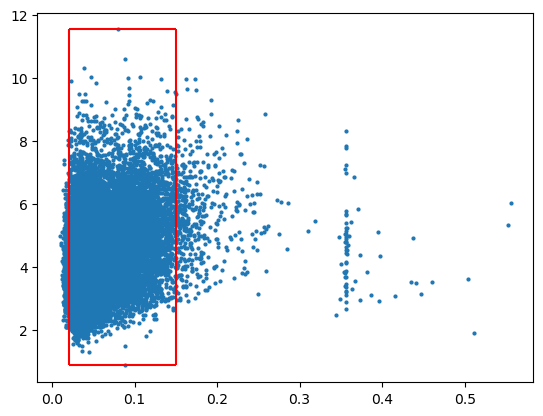

In [4]:
x_lim = (0.02, 0.15)
plt.scatter(error_list, speed_list, s=4)
plt.hlines(max(speed_list), x_lim[0], x_lim[1], color="r")
plt.hlines(min(speed_list), x_lim[0], x_lim[1], color="r")
plt.vlines(x_lim[1], min(speed_list), max(speed_list), color="r")
plt.vlines(x_lim[0], min(speed_list), max(speed_list), color="r")
plt.show()

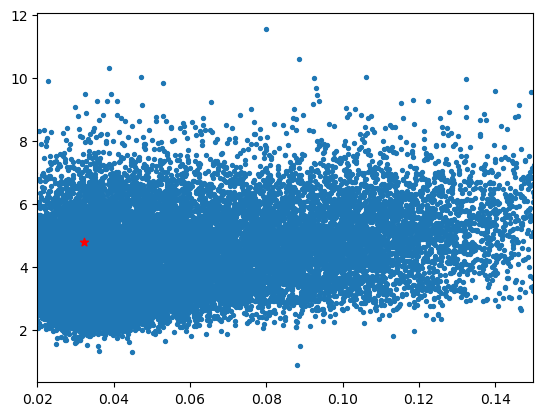

Arquitetura escolhida: epochs_300__batch_1000__arch_Tanh--8__ReLU--32__Elu--16__ReLU--32__
Erro absoluto médio 0.005322419
Erro absoluto máximo 0.026949704
Speed Up: 5.958486468128629 +/-1.1712075073647024


In [5]:
choice = np.intersect1d(
    np.argwhere(np.array(speed_list) < 5), np.argwhere(np.array(error_list) < 0.04)
)[0]

plt.scatter(error_list, speed_list, s=8)
plt.scatter(error_list[choice], speed_list[choice], c="r", marker="*")
plt.xlim(x_lim[0], x_lim[1])
plt.ylim()
plt.show()

arch_str = results_dict[choice]["arch_name"]

print("Arquitetura escolhida: " + arch_str)
print("Erro absoluto médio", results_dict[choice]["rmse"])
print("Erro absoluto máximo", results_dict[choice]["max_ae"])
print(
    "Speed Up: {} +/-{}".format(
        results_dict[choice]["mean_speed_up"], results_dict[choice]["std_speed_up"]
    )
)

## Comparação entre PINN e NN

In [6]:
with open("learning_curves/C_pde_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_pde_loss_it = pk.load(f)

with open("learning_curves/C_data_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_data_loss_it = pk.load(f)

with open("learning_curves/C_initial_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_initial_loss_it = pk.load(f)

results_dict[choice]

with open(results_dict[choice]["file"], "rb") as f:
    aux_dict = pk.load(f)
    Cl_pinn_lin = aux_dict["Cl_pinn"].numpy()
    Cp_pinn_lin = aux_dict["Cp_pinn"].numpy()

size_t = int(len(Cl_pinn_lin) ** 0.5)

struct_name = "k--0.1__phi--0.2__ksi--0.0__cb--0.15__Cn_max--0.55__lambd_nb--1.8__mi_n--0.2__lambd_bn--0.1__y_n--0.1__t_lower--0.0__t_upper--10.0"


with open("edo_fdm_sim/Cp__" + struct_name + ".pkl", "rb") as f:
    Cp = pk.load(f)

with open("edo_fdm_sim/Cl__" + struct_name + ".pkl", "rb") as f:
    Cl = pk.load(f)

Cl_pinn_np = Cl_pinn_lin.reshape(size_t, size_t)
Cp_pinn_np = Cp_pinn_lin.reshape(size_t, size_t)

lmb_var = 0.4

lmb_list = np.linspace(
    1.8 * (1 - lmb_var), 1.8 * (1 + lmb_var), num=size_t, endpoint=True
)

t_np = np.linspace(0, 10, num=size_t, endpoint=True)

tt, ll = np.meshgrid(t_np, lmb_list)

FileNotFoundError: [Errno 2] No such file or directory: 'edo_fdm_sim/Cp__k--0.1__phi--0.2__ksi--0.0__cb--0.15__Cn_max--0.55__lambd_nb--1.8__mi_n--0.2__lambd_bn--0.1__y_n--0.1__t_lower--0.0__t_upper--10.0.pkl'

In [ ]:
data_input_np = np.array([Cl.flatten(), Cp.flatten()]).T

if torch.cuda.is_available():
    device = torch.device("cuda")
    t = (
        torch.tensor(tt, dtype=torch.float32, requires_grad=True)
        .reshape(-1, 1)
        .to(device)
    )
    lambd_nb = (
        torch.tensor(ll, dtype=torch.float32, requires_grad=True)
        .reshape(-1, 1)
        .to(device)
    )
    data_input = torch.tensor(data_input_np, dtype=torch.float32).to(device)

else:
    device = torch.device("cpu")
    t = torch.tensor(tt, dtype=torch.float32, requires_grad=True).reshape(-1, 1)
    lambd_nb = torch.tensor(ll, dtype=torch.float32, requires_grad=True).reshape(-1, 1)
    data_input = torch.tensor(data_input_np, dtype=torch.float32)

n_epochs = int(arch_str.split("__")[0].split("_")[-1])
batch_size = int(arch_str.split("__")[1].split("_")[-1])
model = generate_model(arch_str.split("arch_")[-1]).to(device)

model, nn_loss = train_data(
    n_epochs=n_epochs,
    batch_size=batch_size,
    decay_rate=0.99,
    model=model,
    lambd_nb=lambd_nb,
    device=device,
    data_input=data_input,
    t=t,
)

mesh = torch.cat([t, lambd_nb], dim=1)
with torch.no_grad():
    Cl_pinn_data, Cp_pinn_data = model(mesh).split(1, dim=1)

Cl_pinn_data_np = Cl_pinn_data.reshape(size_t, size_t).cpu().numpy()
Cp_pinn_data_np = Cp_pinn_data.reshape(size_t, size_t).cpu().numpy()

Finished epoch 0, latest loss 0.07349178940057755
Finished epoch 100, latest loss 0.000811345293186605
Finished epoch 200, latest loss 0.0007386129582300782
Finished epoch 300, latest loss 0.000699515687301755
Finished epoch 400, latest loss 0.0002732505090534687
Finished epoch 500, latest loss 0.0003513524425216019


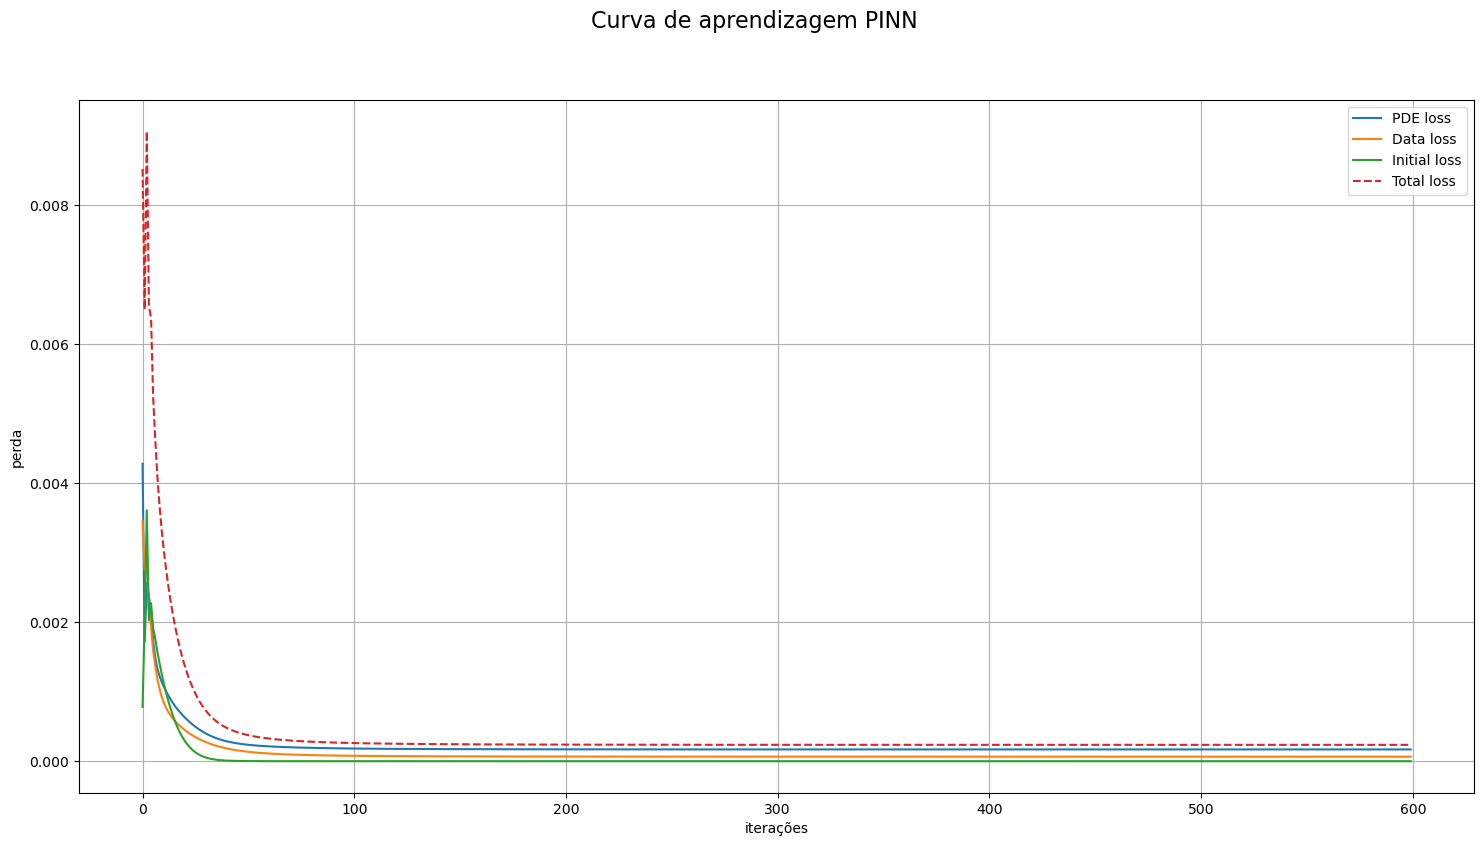

In [ ]:
fig = plt.figure(figsize=[18, 9])

fig.suptitle("Curva de aprendizagem PINN", fontsize=16)

# Plotango 3D
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel("iterações")
ax.set_ylabel("perda")
ax.plot(
    range(len(C_pde_loss_it)),
    C_pde_loss_it,
    label="PDE loss",
)
ax.plot(
    range(len(C_data_loss_it)),
    C_data_loss_it,
    label="Data loss",
)
ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it,
    label="Initial loss",
)
ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it + C_data_loss_it + C_pde_loss_it,
    "--",
    label="Total loss",
)

# ax.set_yscale("log")
ax.grid()
ax.legend()

plt.show()

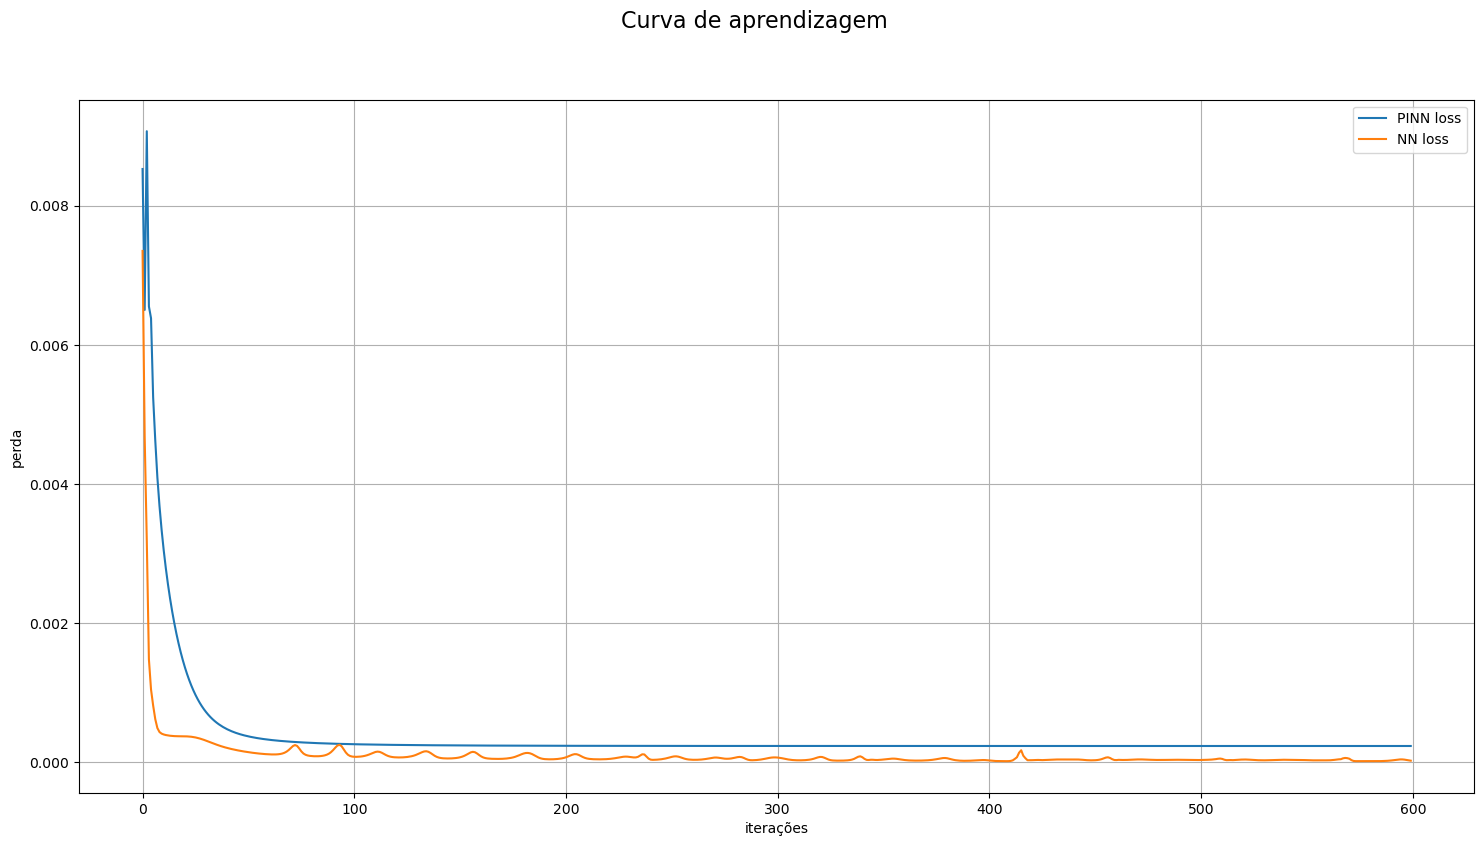

In [ ]:
fig = plt.figure(figsize=[18, 9])

fig.suptitle("Curva de aprendizagem", fontsize=16)

# Plotango 3D
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel("iterações")
ax.set_ylabel("perda")

ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it + C_data_loss_it + C_pde_loss_it,
    label="PINN loss",
)
ax.plot(
    range(len(C_initial_loss_it)),
    nn_loss.cpu().numpy(),
    label="NN loss",
)
# ax.set_yscale("log")
ax.grid()
ax.legend()

plt.show()

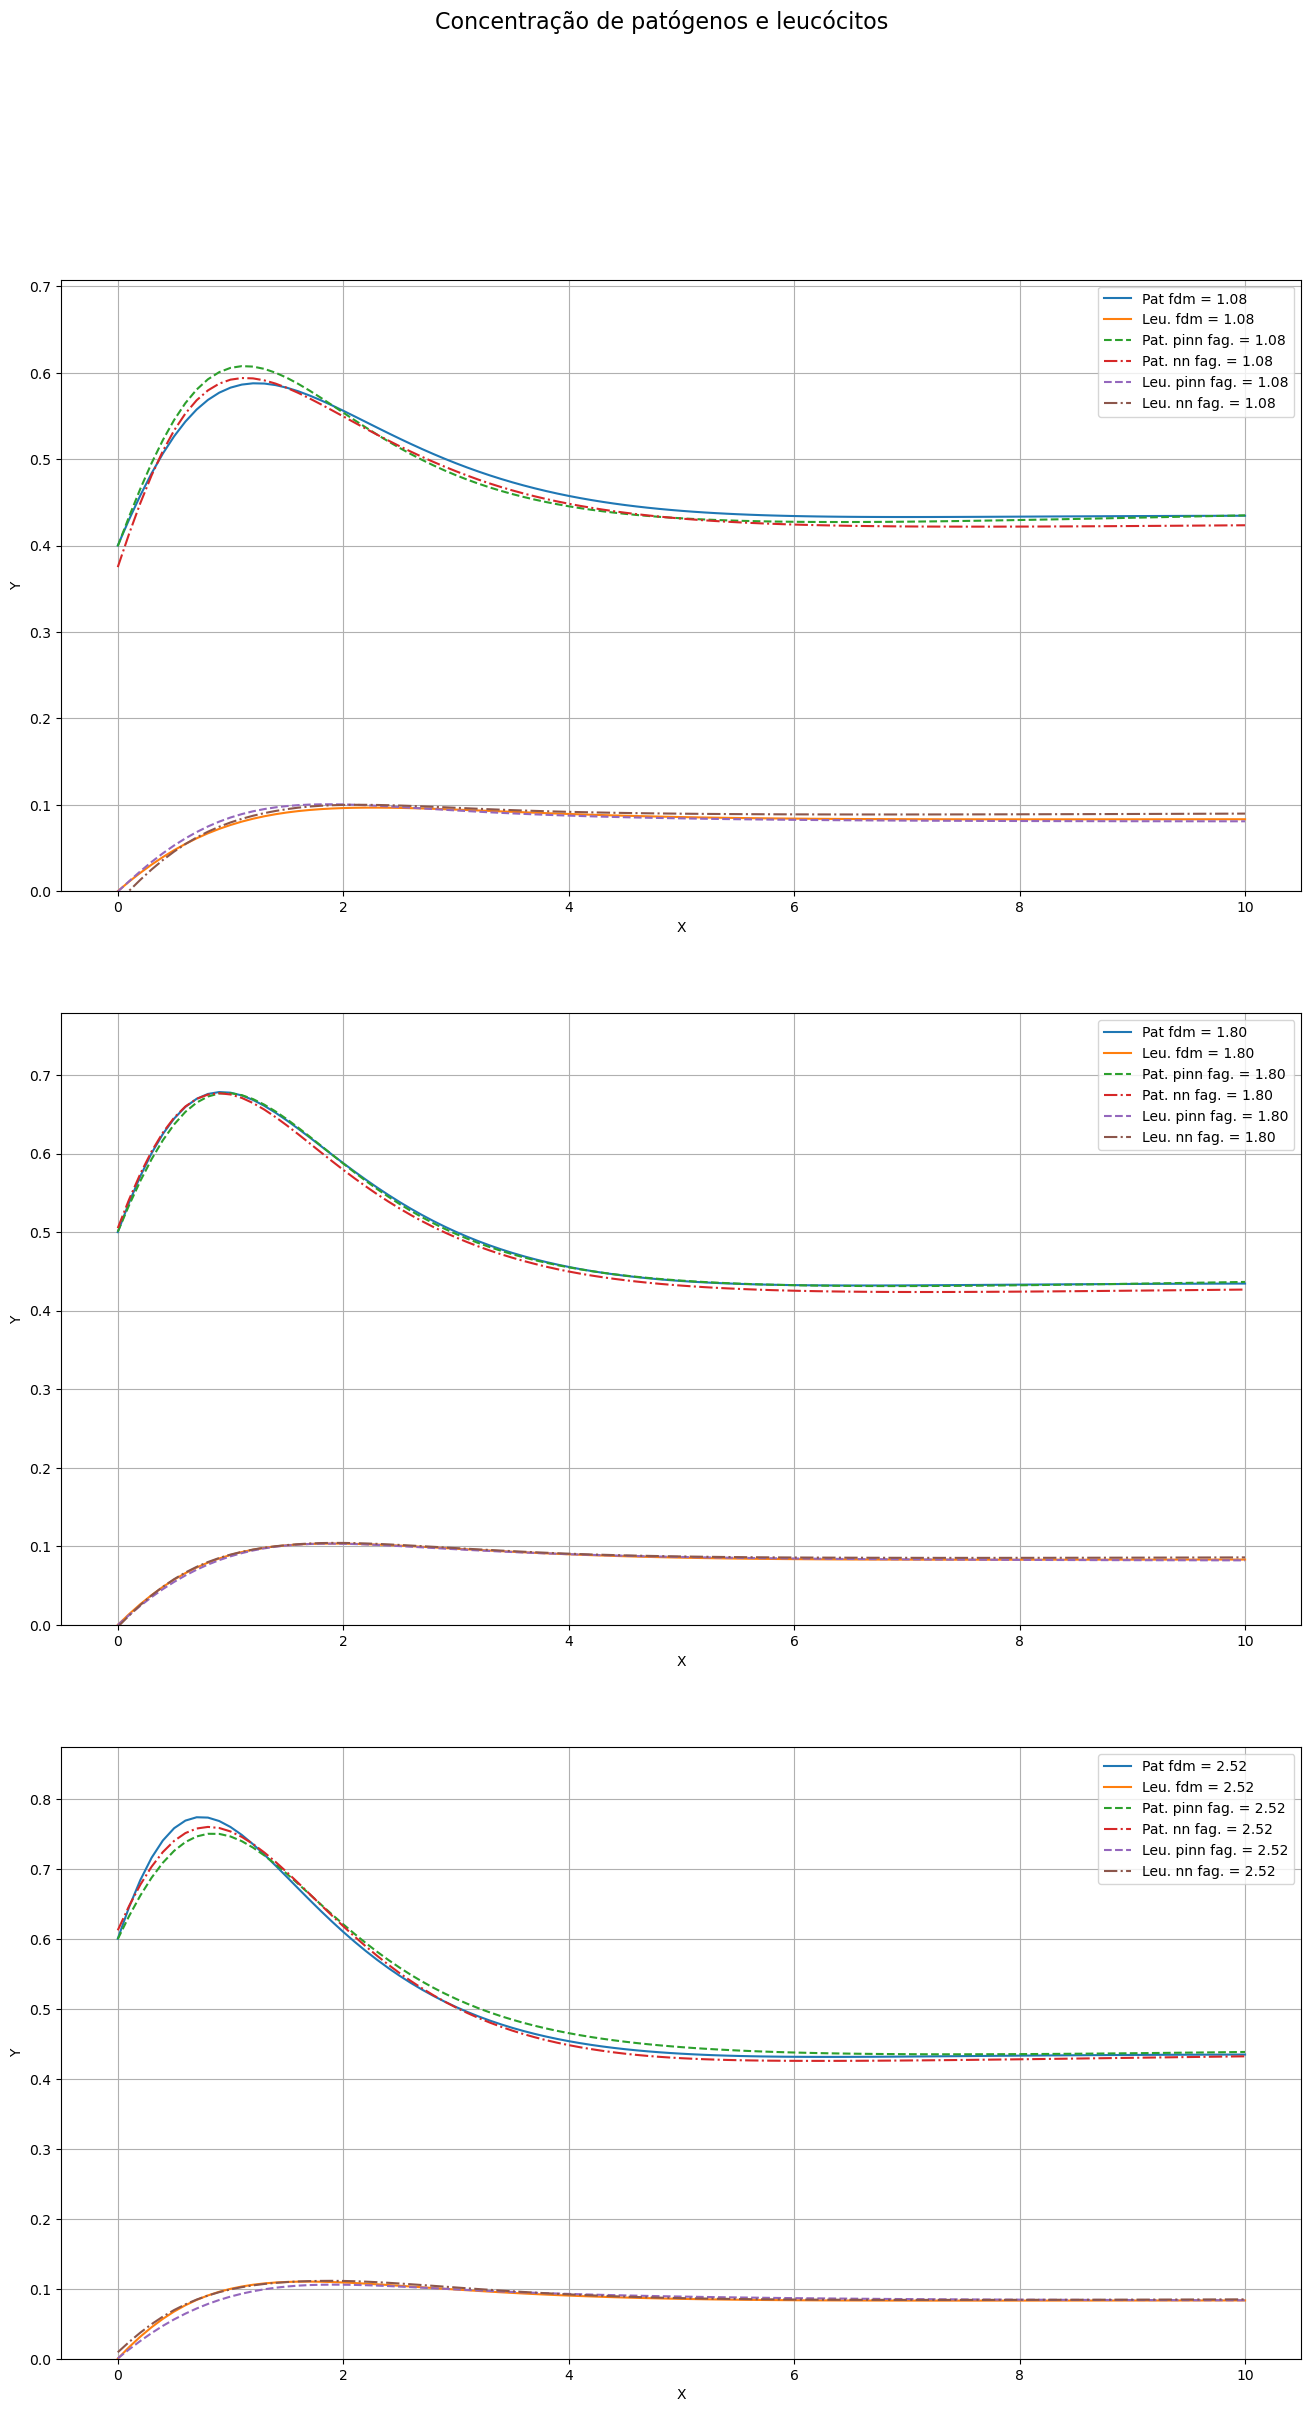

In [ ]:
fig = plt.figure(figsize=[16, 27])

fig.suptitle("Concentração de patógenos e leucócitos", fontsize=16)


vmin = 0

cp_real_1 = Cp[0, :]
cl_real_1 = Cl[0, :]
cp_pinn_1 = Cp_pinn_np[0, :]
cl_pinn_1 = Cl_pinn_np[0, :]
cl_pinn_data_1 = Cl_pinn_data_np[0, :]
cp_pinn_data_1 = Cp_pinn_data_np[0, :]
fag_1 = lmb_list[0]

cp_real_2 = Cp[50, :]
cl_real_2 = Cl[50, :]
cp_pinn_2 = Cp_pinn_np[50, :]
cl_pinn_2 = Cl_pinn_np[50, :]
cl_pinn_data_2 = Cl_pinn_data_np[50, :]
cp_pinn_data_2 = Cp_pinn_data_np[50, :]
fag_2 = lmb_list[50]

cp_real_3 = Cp[100, :]
cl_real_3 = Cl[100, :]
cp_pinn_3 = Cp_pinn_np[100, :]
cl_pinn_3 = Cl_pinn_np[100, :]
cl_pinn_data_3 = Cl_pinn_data_np[100, :]
cp_pinn_data_3 = Cp_pinn_data_np[100, :]
fag_3 = lmb_list[100]

# Plotango 3D
ax = fig.add_subplot(3, 1, 1)

ax.plot(t_np, cp_real_1, label="Pat fdm = {:.2f}".format(fag_1))
ax.plot(t_np, cl_real_1, label="Leu. fdm = {:.2f}".format(fag_1))
ax.plot(t_np, cp_pinn_1, "--", label="Pat. pinn fag. = {:.2f}".format(fag_1))
ax.plot(t_np, cp_pinn_data_1, "-.", label="Pat. nn fag. = {:.2f}".format(fag_1))
ax.plot(t_np, cl_pinn_1, "--", label="Leu. pinn fag. = {:.2f}".format(fag_1))
ax.plot(t_np, cl_pinn_data_1, "-.", label="Leu. nn fag. = {:.2f}".format(fag_1))
ax.set_xlabel("X")
ax.set_ylabel("Y")

vmax = np.max(
    [
        np.max(cp_real_1),
        np.max(cl_real_1),
        np.max(cp_pinn_1),
        np.max(cl_pinn_1),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

ax = fig.add_subplot(3, 1, 2)

ax.plot(t_np, cp_real_2, label="Pat fdm = {:.2f}".format(fag_2))
ax.plot(t_np, cl_real_2, label="Leu. fdm = {:.2f}".format(fag_2))
ax.plot(t_np, cp_pinn_2, "--", label="Pat. pinn fag. = {:.2f}".format(fag_2))
ax.plot(t_np, cp_pinn_data_2, "-.", label="Pat. nn fag. = {:.2f}".format(fag_2))
ax.plot(t_np, cl_pinn_2, "--", label="Leu. pinn fag. = {:.2f}".format(fag_2))
ax.plot(t_np, cl_pinn_data_2, "-.", label="Leu. nn fag. = {:.2f}".format(fag_2))
ax.set_xlabel("X")
ax.set_ylabel("Y")
vmax = np.max(
    [
        np.max(cp_real_2),
        np.max(cl_real_2),
        np.max(cp_pinn_2),
        np.max(cl_pinn_2),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

ax = fig.add_subplot(3, 1, 3)

ax.plot(t_np, cp_real_3, label="Pat fdm = {:.2f}".format(fag_3))
ax.plot(t_np, cl_real_3, label="Leu. fdm = {:.2f}".format(fag_3))
ax.plot(t_np, cp_pinn_3, "--", label="Pat. pinn fag. = {:.2f}".format(fag_3))
ax.plot(t_np, cp_pinn_data_3, "-.", label="Pat. nn fag. = {:.2f}".format(fag_3))
ax.plot(t_np, cl_pinn_3, "--", label="Leu. pinn fag. = {:.2f}".format(fag_3))
ax.plot(t_np, cl_pinn_data_3, "-.", label="Leu. nn fag. = {:.2f}".format(fag_3))
ax.set_xlabel("X")
ax.set_ylabel("Y")
vmax = np.max(
    [
        np.max(cp_real_3),
        np.max(cl_real_3),
        np.max(cp_pinn_3),
        np.max(cl_pinn_3),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

plt.show()

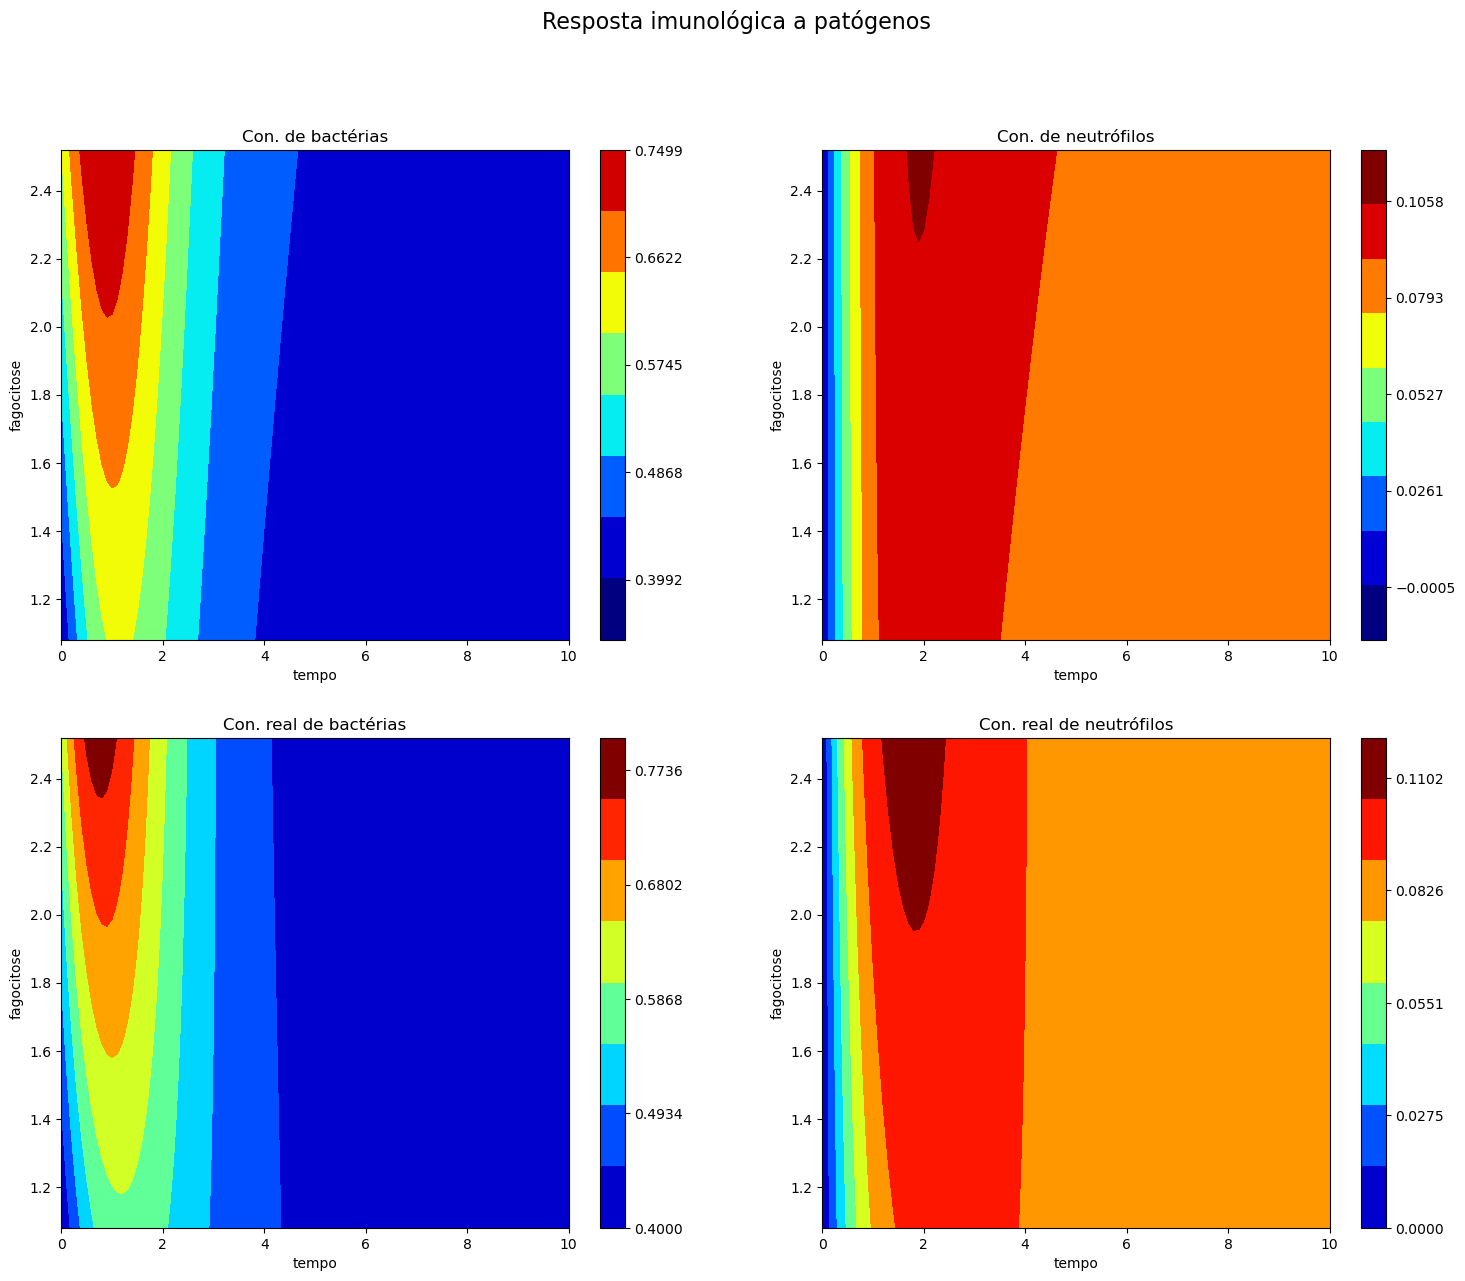

Speed Up: 4.4575637893872075 +/-0.8367855428751062


In [ ]:
fig = plt.figure(figsize=[18, 14])

fig.suptitle("Resposta imunológica a patógenos", fontsize=16)

vmin = np.min(Cp_pinn_np)
vmax = np.max(Cp_pinn_np)

# Plotango 3D
ax = fig.add_subplot(2, 2, 1)

contour = ax.contourf(
    tt,
    ll,
    Cp_pinn_np,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Con. de bactérias")
ax.set_xlabel("tempo")
ax.set_ylabel("fagocitose")
colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

# Plotando 2D

ax = fig.add_subplot(2, 2, 2)

vmin = np.min(Cl_pinn_np)
vmax = np.max(Cl_pinn_np)

contour = ax.contourf(
    tt,
    ll,
    Cl_pinn_np,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Con. de neutrófilos")
ax.set_xlabel("tempo")
ax.set_ylabel("fagocitose")

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

# Plotango 3D
ax = fig.add_subplot(2, 2, 3)

vmin = np.min(Cp)
vmax = np.max(Cp)

contour = ax.contourf(
    tt,
    ll,
    Cp.reshape(size_t, size_t),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Con. real de bactérias")
ax.set_xlabel("tempo")
ax.set_ylabel("fagocitose")
colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

# Plotando 2D

ax = fig.add_subplot(2, 2, 4)

vmin = np.min(Cl)
vmax = np.max(Cl)

contour = ax.contourf(
    tt,
    ll,
    Cl.reshape(size_t, size_t),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Con. real de neutrófilos")
ax.set_xlabel("tempo")
ax.set_ylabel("fagocitose")

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

plt.show()

print(
    "Speed Up: {} +/-{}".format(
        results_dict[choice]["mean_speed_up"], results_dict[choice]["std_speed_up"]
    )
)

# 24/07/17 - Estudos de redes com de 3 a 4 camadas e de 8 a 32 neurônios e validação no treino



## Resumo

- Função de perda: RMSE
- Parânmetros do modelo: k--0.1__phi--0.2__ksi--0.0__cb--0.15__Cn_max--0.55__lambd_nb--1.8__mi_n--0.2__lambd_bn--0.1__y_n--0.1__t_lower--0.0__t_upper--10.0
- Funções de  ativação: 
    - Elu 
    - Tanh
    - ReLU
    - SiLU

- Tamanhos de batelada e épocas:
    - (10000, 300)

- Arquivo de checkpoint: 1721243952

- Peso da perda de cond. inicial: 10

- Peso da perda de dados: 10

- Condição inicial: 0.5

- Variação da condição inicial: 0.2 (0.4-0.6)

- Parcela de validação: 10%


## Análise de erro vs speedup

In [1]:
import glob
import pickle as pk
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tools import generate_model, train_data

In [2]:
result_list = glob.glob("edo_pinn_sim/*")

print("numero de arquiteturas testadas: {}".format(len(result_list)))

numero de arquiteturas testadas: 22465


In [3]:
results_dict = {}

error_list = []

speed_list = []

for file in result_list:
    i = len(error_list)
    if file.split(".")[-1] == "pkl":
        with open(file, "rb") as f:
            aux_dict = pk.load(f)

        results_dict[i] = {
            "rmse": aux_dict["rmse"],
            "max_ae": aux_dict["max_ae"],
            "mean_speed_up": aux_dict["mean_speed_up"],
            "std_speed_up": aux_dict["std_speed_up"],
            "arch_name": file.split("/")[-1].split(".")[0],
            "file": file,
        }

        results_dict[i]["arch_name"] = file.split("/")[-1].split(".")[0]

        error_list.append(results_dict[i]["rmse"] + results_dict[i]["max_ae"])
        speed_list.append(
            results_dict[i]["mean_speed_up"] - results_dict[i]["std_speed_up"]
        )

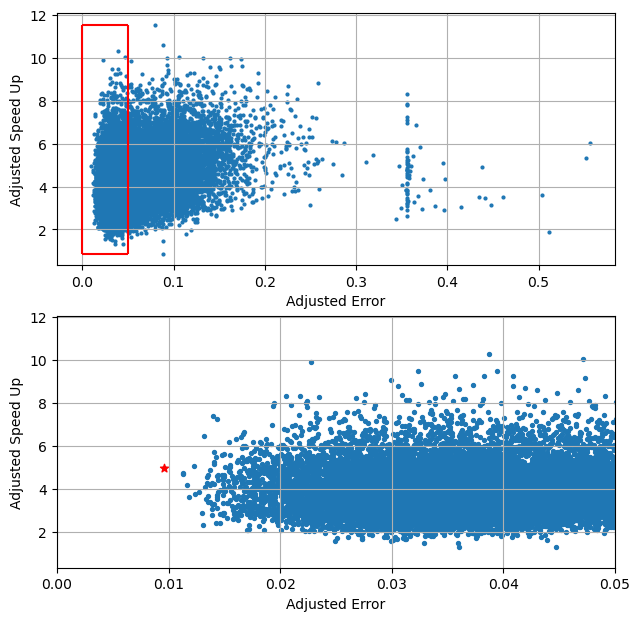

Arquitetura escolhida: epochs_300__batch_1000__arch_Tanh--16__SiLU--8__ReLU--32__ReLU--16__
Erro absoluto médio 0.001530657
Erro absoluto máximo 0.0080879815
Speed Up: 5.930424065230464 +/-0.9676166975104605


In [4]:
x_lim = (0.0, 0.05)

fig = plt.figure(figsize=[12*0.6, 12*0.6])

# fig.suptitle("Curva de aprendizagem", fontsize=16)

ax = fig.add_subplot(2, 1, 1)

ax.scatter(error_list, speed_list, s=4)
ax.hlines(max(speed_list), x_lim[0], x_lim[1], color="r")
ax.hlines(min(speed_list), x_lim[0], x_lim[1], color="r")
ax.vlines(x_lim[1], min(speed_list), max(speed_list), color="r")
ax.vlines(x_lim[0], min(speed_list), max(speed_list), color="r")

choice = np.intersect1d(
    np.argwhere(np.array(speed_list) > 4), np.argwhere(np.array(error_list) < 0.01)
)[0]

ax.set_xlabel("Adjusted Error")
ax.set_ylabel("Adjusted Speed Up")

ax.grid()

ax = fig.add_subplot(2, 1, 2)

ax.scatter(error_list, speed_list, s=8)
ax.scatter(error_list[choice], speed_list[choice], c="r", marker="*")
ax.set_xlim(x_lim[0], x_lim[1])

ax.set_xlabel("Adjusted Error")
ax.set_ylabel("Adjusted Speed Up")

ax.grid()

plt.show()

arch_str = results_dict[choice]["arch_name"]

print("Arquitetura escolhida: " + arch_str)
print("Erro absoluto médio", results_dict[choice]["rmse"])
print("Erro absoluto máximo", results_dict[choice]["max_ae"])
print(
    "Speed Up: {} +/-{}".format(
        results_dict[choice]["mean_speed_up"], results_dict[choice]["std_speed_up"]
    )
)


In [5]:
with open("learning_curves/C_pde_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_pde_loss_it = pk.load(f)

with open("learning_curves/C_data_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_data_loss_it = pk.load(f)

with open("learning_curves/C_initial_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_initial_loss_it = pk.load(f)

with open("learning_curves/C_initial_loss_it__" + arch_str + ".pkl", "rb") as f:
    C_initial_loss_it = pk.load(f)

with open("learning_curves/val_loss_it__" + arch_str + ".pkl", "rb") as f:
    val_loss_it= pk.load(f)

results_dict[choice]

with open(results_dict[choice]["file"], "rb") as f:
    aux_dict = pk.load(f)
    Cl_pinn_lin = aux_dict["Cl_pinn"].numpy()
    Cp_pinn_lin = aux_dict["Cp_pinn"].numpy()

size_t = int(len(Cl_pinn_lin) ** 0.5)

struct_name = "k--0.1__phi--0.2__ksi--0.0__cb--0.15__Cn_max--0.55__lambd_nb--1.8__mi_n--0.2__lambd_bn--0.1__y_n--0.1__t_lower--0.0__t_upper--10__initial--0.5"


with open("edo_fdm_sim/Cp__" + struct_name + ".pkl", "rb") as f:
    Cp = pk.load(f)

with open("edo_fdm_sim/Cl__" + struct_name + ".pkl", "rb") as f:
    Cl = pk.load(f)

Cl_pinn_np = Cl_pinn_lin.reshape(size_t, size_t)
Cp_pinn_np = Cp_pinn_lin.reshape(size_t, size_t)

initial = 0.5
t_lower = 0.0
t_upper = 10
k=0.1

size_t = int(((t_upper - t_lower) / (k)))

initial_var = 0.2

initial = np.linspace(
    initial * (1 - initial_var),
    initial * (1 + initial_var),
    num=size_t + 1,
    endpoint=True,
)
t_np = np.linspace(0, 10, num=size_t +1, endpoint=True)

tt, ii = np.meshgrid(t_np, initial)

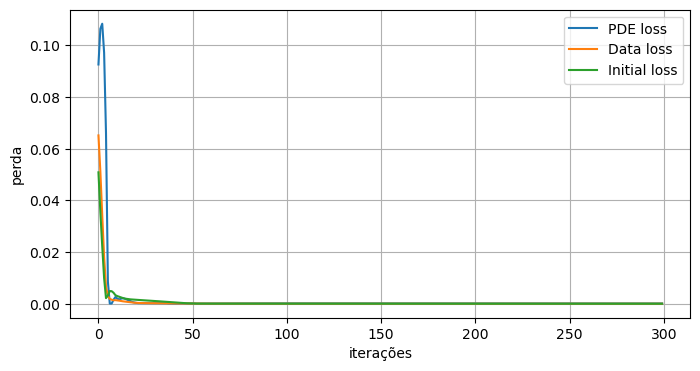

In [6]:
scale_factor = 0.5
fig = plt.figure(figsize=[16*scale_factor, 8*scale_factor])

# fig.suptitle("Curva de aprendizagem", fontsize=16)

# Plotango 3D
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel("iterações")
ax.set_ylabel("perda")
ax.plot(
    range(len(C_pde_loss_it)),
    C_pde_loss_it,
    label="PDE loss",
)
ax.plot(
    range(len(C_data_loss_it)),
    C_data_loss_it,
    label="Data loss",
)
ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it,
    label="Initial loss",
)
# ax.set_yscale("log")
ax.grid()
ax.legend()

plt.show()

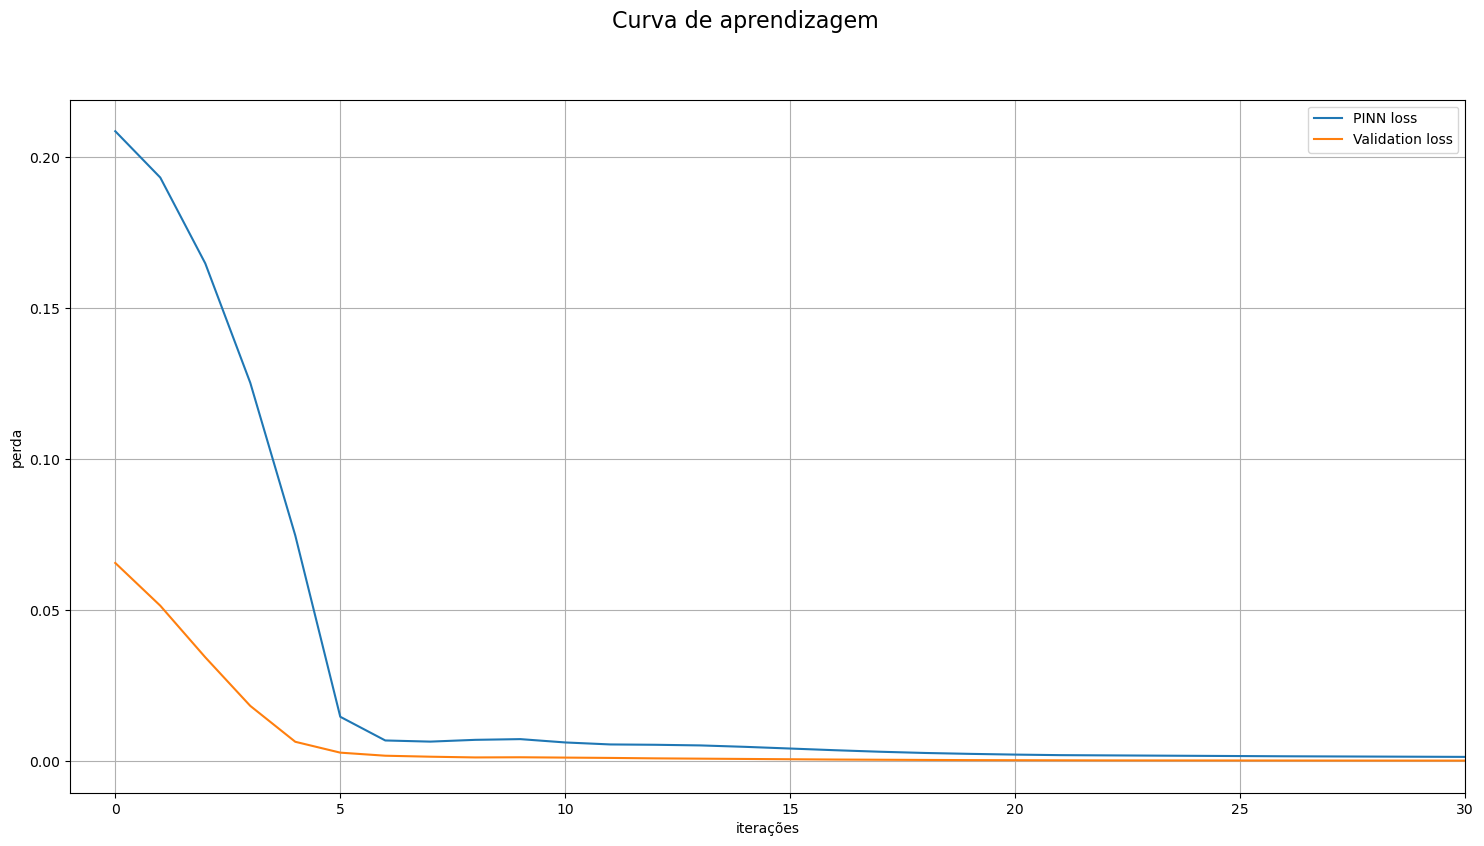

In [7]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=[18, 9])

fig.suptitle("Curva de aprendizagem", fontsize=16)

# Plotango 3D
ax = fig.add_subplot(1, 1, 1)

ax.set_xlabel("iterações")
ax.set_ylabel("perda")

ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it+C_pde_loss_it+C_data_loss_it,
    label="PINN loss",
)
ax.plot(
    range(len(val_loss_it)),
    val_loss_it,
    label="Validation loss",
)
# ax.set_yscale("log")
ax.grid()
ax.legend()
ax.set_xlim(-1,30)

plt.show()

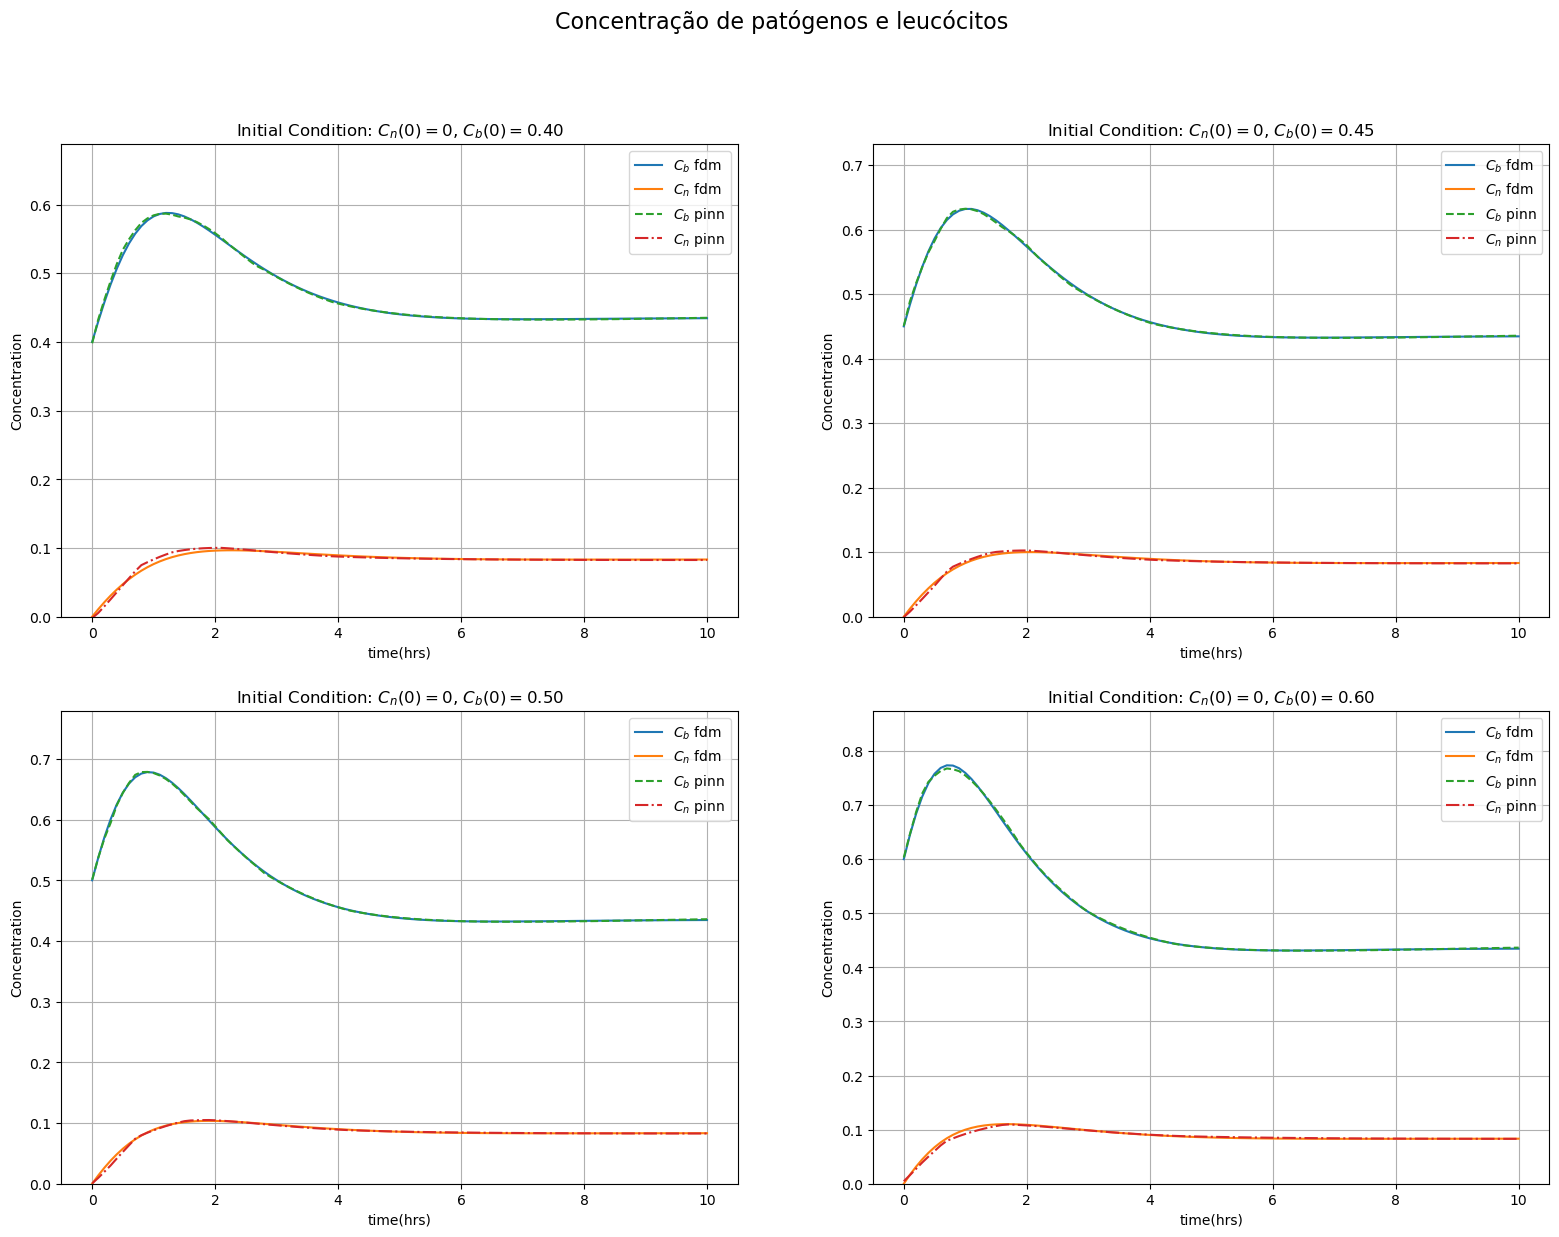

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=[16*1.2, 9*1.5])

fig.suptitle("Concentração de patógenos e leucócitos", fontsize=16)


vmin = 0

cp_real_1 = Cp[0, :]
cl_real_1 = Cl[0, :]
cp_pinn_1 = Cp_pinn_np[0, :]
cl_pinn_1 = Cl_pinn_np[0, :]
ini_1 = initial[0]

cp_real_2 = Cp[25, :]
cl_real_2 = Cl[25, :]
cp_pinn_2 = Cp_pinn_np[25, :]
cl_pinn_2 = Cl_pinn_np[25, :]
ini_2 = initial[25]

cp_real_3 = Cp[50, :]
cl_real_3 = Cl[50, :]
cp_pinn_3 = Cp_pinn_np[50, :]
cl_pinn_3 = Cl_pinn_np[50, :]
ini_3 = initial[50]


cp_real_4 = Cp[100, :]
cl_real_4 = Cl[100, :]
cp_pinn_4 = Cp_pinn_np[100, :]
cl_pinn_4 = Cl_pinn_np[100, :]
ini_4 = initial[100]

# Plotango 3D
ax = fig.add_subplot(2, 2, 1)
ax.set_title("Initial Condition: $C_n(0) = 0$, $C_b(0) = {:.2f}$".format(ini_1))

ax.plot(t_np, cp_real_1, label="$C_b$ fdm")
ax.plot(t_np, cl_real_1, label="$C_n$ fdm")
ax.plot(t_np, cp_pinn_1, "--", label="$C_b$ pinn")
ax.plot(t_np, cl_pinn_1, "-.", label="$C_n$ pinn")
ax.set_xlabel("time(hrs)")
ax.set_ylabel("Concentration")

vmax = np.max(
    [
        np.max(cp_real_1),
        np.max(cl_real_1),
        np.max(cp_pinn_1),
        np.max(cl_pinn_1),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

ax = fig.add_subplot(2,2, 2)
ax.set_title("Initial Condition: $C_n(0) = 0$, $C_b(0) = {:.2f}$".format(ini_2))

ax.plot(t_np, cp_real_2, label="$C_b$ fdm")
ax.plot(t_np, cl_real_2, label="$C_n$ fdm")
ax.plot(t_np, cp_pinn_2, "--", label="$C_b$ pinn")
ax.plot(t_np, cl_pinn_2, "-.", label="$C_n$ pinn")
ax.set_xlabel("time(hrs)")
ax.set_ylabel("Concentration")
vmax = np.max(
    [
        np.max(cp_real_2),
        np.max(cl_real_2),
        np.max(cp_pinn_2),
        np.max(cl_pinn_2),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

ax = fig.add_subplot(2,2, 3)
ax.set_title("Initial Condition: $C_n(0) = 0$, $C_b(0) = {:.2f}$".format(ini_3))

ax.plot(t_np, cp_real_3, label="$C_b$ fdm")
ax.plot(t_np, cl_real_3, label="$C_n$ fdm")
ax.plot(t_np, cp_pinn_3, "--", label="$C_b$ pinn")
ax.plot(t_np, cl_pinn_3, "-.", label="$C_n$ pinn")
ax.set_xlabel("time(hrs)")
ax.set_ylabel("Concentration")
vmax = np.max(
    [
        np.max(cp_real_3),
        np.max(cl_real_3),
        np.max(cp_pinn_3),
        np.max(cl_pinn_3),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

ax = fig.add_subplot(2,2, 4)
ax.set_title("Initial Condition: $C_n(0) = 0$, $C_b(0) = {:.2f}$".format(ini_4))

ax.plot(t_np, cp_real_4, label="$C_b$ fdm")
ax.plot(t_np, cl_real_4, label="$C_n$ fdm")
ax.plot(t_np, cp_pinn_4, "--", label="$C_b$ pinn")
ax.plot(t_np, cl_pinn_4, "-.", label="$C_n$ pinn")
ax.set_xlabel("time(hrs)")
ax.set_ylabel("Concentration")
vmax = np.max(
    [
        np.max(cp_real_4),
        np.max(cl_real_4),
        np.max(cp_pinn_4),
        np.max(cl_pinn_4),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

plt.show()

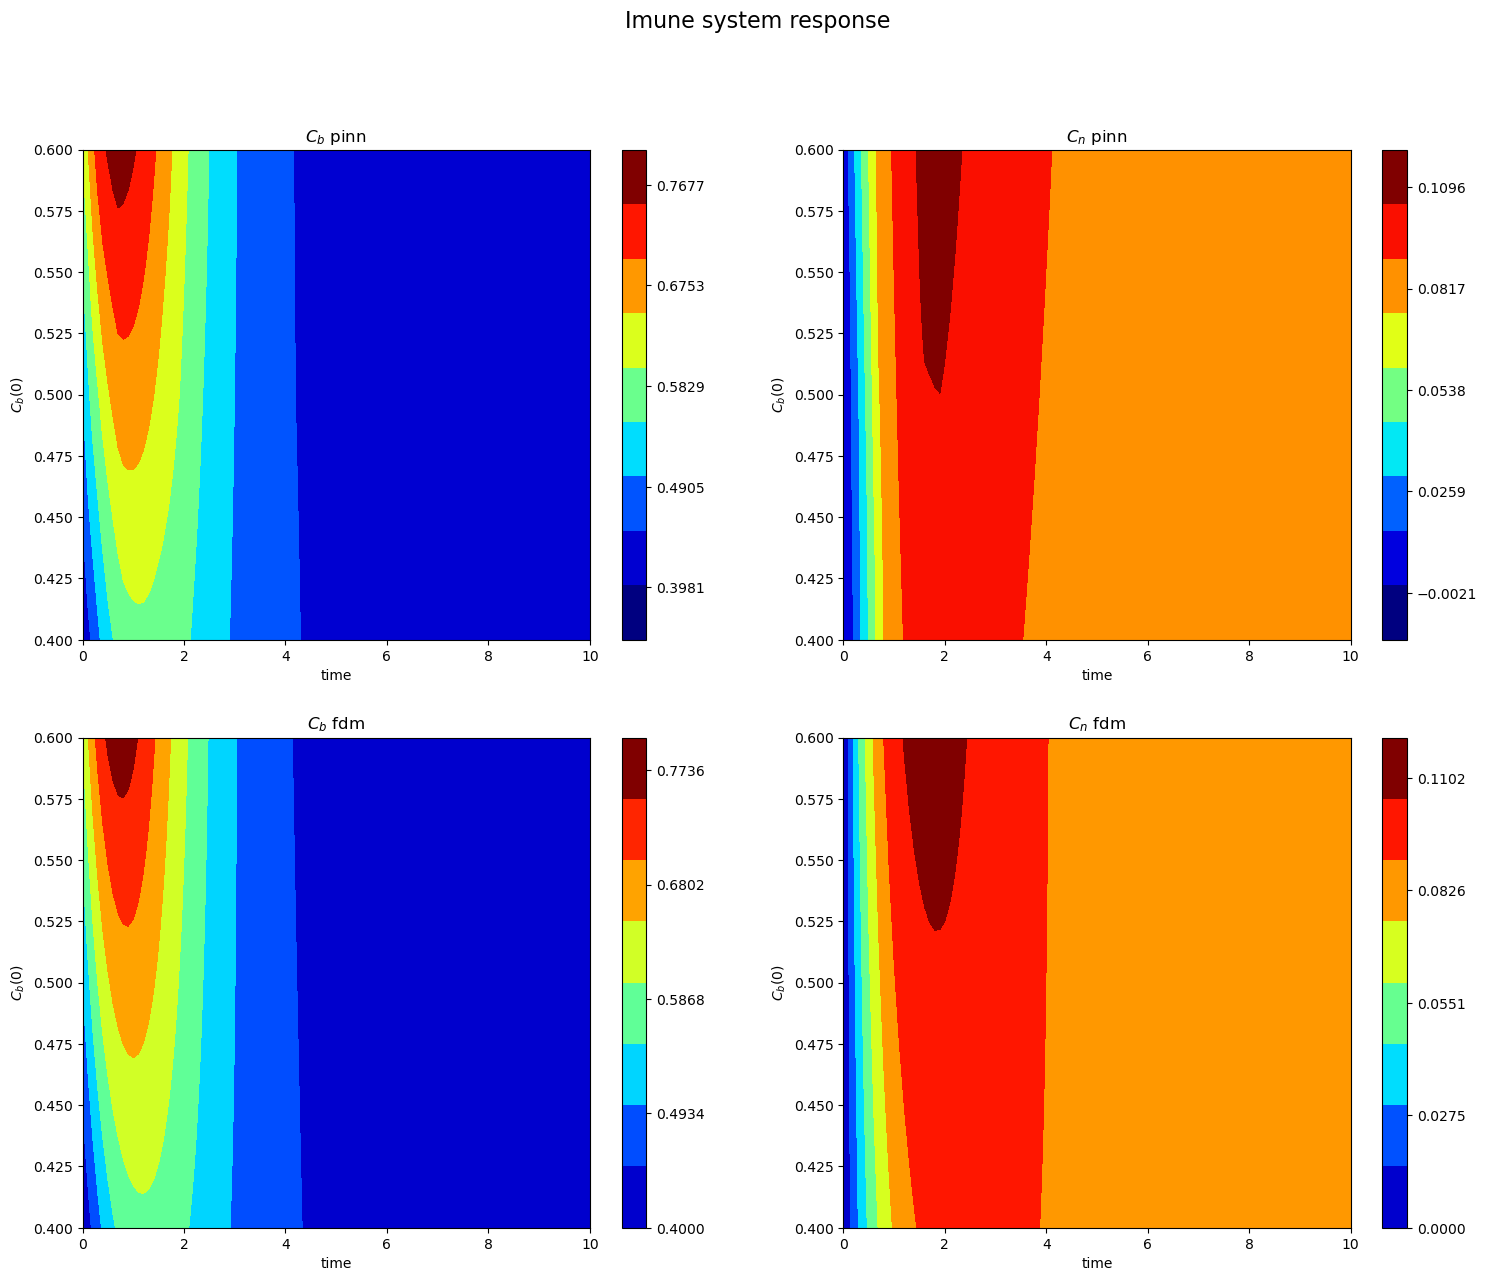

In [9]:

fig = plt.figure(figsize=[18, 14])

fig.suptitle("Imune system response", fontsize=16)


# Plotango 3D
ax = fig.add_subplot(2, 2, 1)

vmin = np.min(Cp_pinn_np)
vmax = np.max(Cp_pinn_np)

contour = ax.contourf(
    tt,
    ii,
    Cp_pinn_np,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_b$ pinn")
ax.set_xlabel("time")
ax.set_ylabel("$C_b(0)$")
colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

# Plotando 2D

ax = fig.add_subplot(2, 2, 2)

vmin = np.min(Cl_pinn_np)
vmax = np.max(Cl_pinn_np)

contour = ax.contourf(
    tt,
    ii,
    Cl_pinn_np,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_n$ pinn")
ax.set_xlabel("time")
ax.set_ylabel("$C_b(0)$")

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

# Plotango 3D
ax = fig.add_subplot(2, 2, 3)

vmin = np.min(Cp)
vmax = np.max(Cp)

contour = ax.contourf(
    tt,
    ii,
    Cp.reshape(size_t + 1, size_t + 1),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_b$ fdm")
ax.set_xlabel("time")
ax.set_ylabel("$C_b(0)$")
colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

# Plotando 2D

ax = fig.add_subplot(2, 2, 4)

vmin = np.min(Cl)
vmax = np.max(Cl)

contour = ax.contourf(
    tt,
    ii,
    Cl.reshape(size_t + 1, size_t + 1),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_n$ fdm")
ax.set_xlabel("time")
ax.set_ylabel("$C_b(0)$")

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

plt.show()

## Comparação com NN

In [29]:
data_input_np = np.array([Cl.flatten(), Cp.flatten()]).T

if torch.cuda.is_available():
    device = torch.device("cuda")
    t = (
        torch.tensor(tt, dtype=torch.float32, requires_grad=True)
        .reshape(-1, 1)
        .to(device)
    )
    initial_tc = (
        torch.tensor(ii, dtype=torch.float32, requires_grad=True)
        .reshape(-1, 1)
        .to(device)
    )
    data_input = torch.tensor(data_input_np, dtype=torch.float32).to(device)

else:
    device = torch.device("cpu")
    t = torch.tensor(tt, dtype=torch.float32, requires_grad=True).reshape(-1, 1)
    initial_tc = torch.tensor(ii, dtype=torch.float32, requires_grad=True).reshape(-1, 1)
    data_input = torch.tensor(data_input_np, dtype=torch.float32)

n_epochs = int(arch_str.split("__")[0].split("_")[-1])
batch_size = int(arch_str.split("__")[1].split("_")[-1])
model = generate_model(arch_str.split("arch_")[-1]).to(device)

model, nn_loss, nn_val_loss = train_data(
    n_epochs=n_epochs,
    batch_size=batch_size,
    decay_rate=0.999,
    model=model,
    initial=initial_tc,
    device=device,
    data_input=data_input,
    t=t,
    validation=0.1,
    norm_weights=None,
)

mesh = torch.cat([t, initial_tc], dim=1)
with torch.no_grad():
    Cl_nn_data, Cp_nn_data = model(mesh).cpu().split(1, dim=1)


Cl_nn_data = Cl_nn_data.detach().numpy().reshape(size_t + 1, size_t + 1)
Cp_nn_data = Cp_nn_data.detach().numpy().reshape(size_t + 1, size_t + 1)


0 1
Finished epoch 1, latest loss 0.1917007863521576, validation loss 0.18174755573272705
Finished epoch 101, latest loss 0.000513677136041224, validation loss 0.00042930024210363626
Finished epoch 201, latest loss 0.00029575673397630453, validation loss 0.00024260416103061289


In [30]:
rmse = np.mean(
    [
        ((Cl_p[0] - Cl_f) ** 2 + (Cp_p[0] - Cp_f) ** 2) ** 0.5
        for Cl_p, Cp_p, Cl_f, Cp_f in zip(
            Cl_nn_data, Cp_nn_data, Cl.flatten(), Cp.flatten()
        )
    ]
)

max_ae = np.max(
    [
        [((Cl_p[0] - Cl_f) ** 2) ** 0.5, ((Cp_p[0] - Cp_f) ** 2) ** 0.5]
        for Cl_p, Cp_p, Cl_f, Cp_f in zip(
            Cl_nn_data, Cp_nn_data, Cl.flatten(), Cp.flatten()
        )
    ]
)

print("Erro absoluto médio", rmse)
print("Erro absoluto máximo", max_ae)

Erro absoluto médio 0.09885553790621215
Erro absoluto máximo 0.13526527543583355


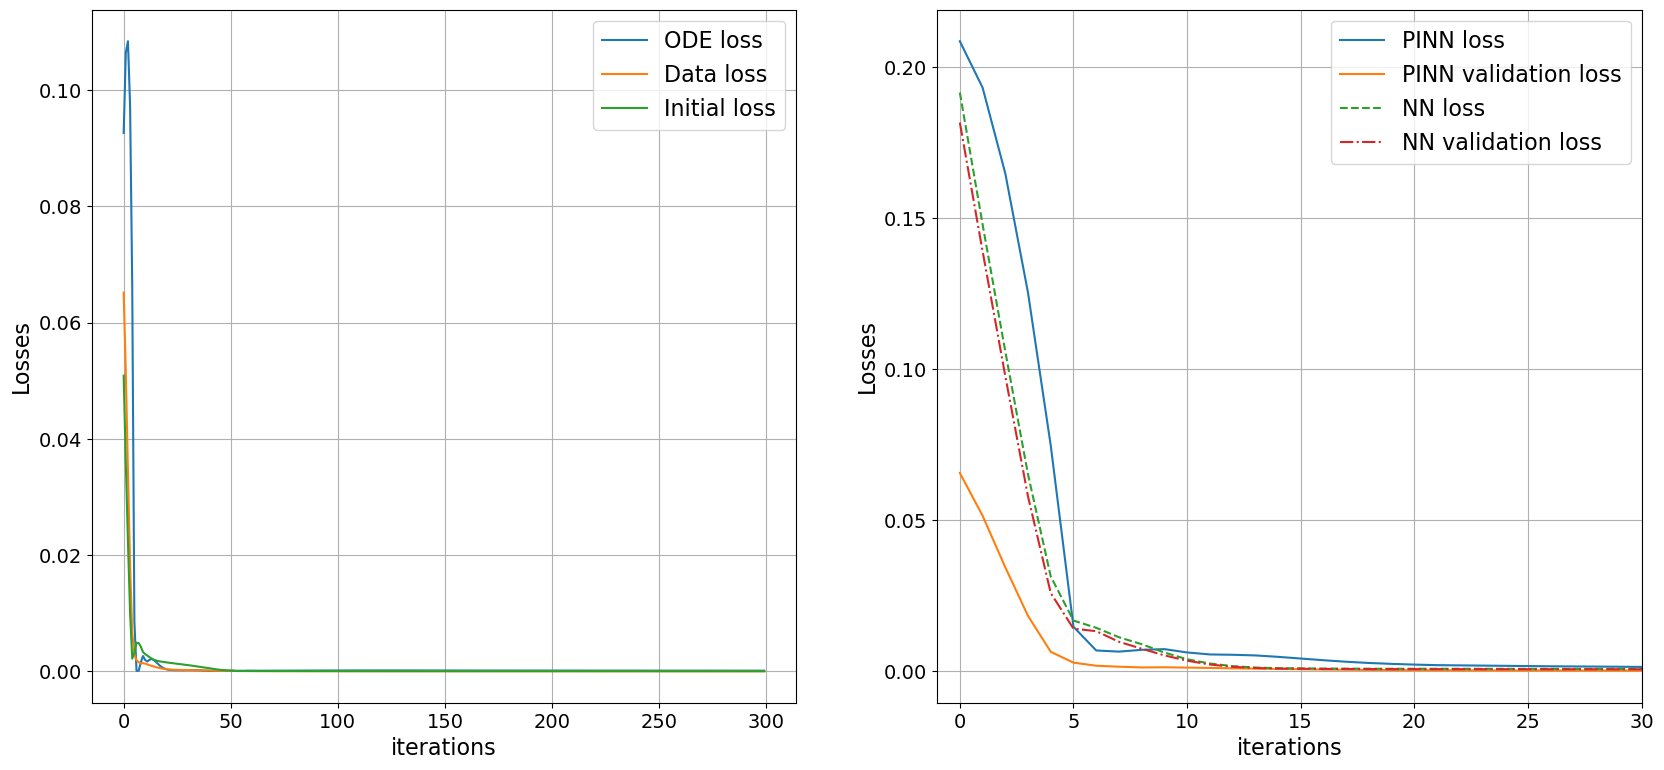

In [31]:
scale_factor = 1

fig = plt.figure(figsize=[20 * scale_factor, 9 * scale_factor])

# fig.suptitle("Curva de aprendizagem", fontsize=16)

ax = fig.add_subplot(1, 2, 1)

ax.set_xlabel("iterations",fontsize=16)
ax.set_ylabel("Losses",fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

ax.plot(
    range(len(C_pde_loss_it)),
    C_pde_loss_it,
    label="ODE loss",
)
ax.plot(
    range(len(C_data_loss_it)),
    C_data_loss_it,
    label="Data loss",
)
ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it,
    label="Initial loss",
)

# ax.set_yscale("log")
ax.grid()
ax.legend(prop={'size': 16})

ax = fig.add_subplot(1, 2, 2)

ax.set_xlabel("iterations",fontsize=16)
ax.set_ylabel("Losses",fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

ax.plot(
    range(len(C_initial_loss_it)),
    C_initial_loss_it+C_pde_loss_it+C_data_loss_it,
    label="PINN loss",
)
ax.plot(
    range(len(val_loss_it)),
    val_loss_it,
    label="PINN validation loss",
)

ax.plot(
    range(len(C_initial_loss_it)),
    nn_loss.cpu().detach().numpy(),
    '--',
    label="NN loss",
)
ax.plot(
    range(len(val_loss_it)),
    nn_val_loss.cpu().detach().numpy(),
    '-.',
    label="NN validation loss",
)
# 
# ax.set_yscale("log")
ax.grid()
ax.legend(prop={'size': 16})
ax.set_xlim(-1,30)

plt.show()

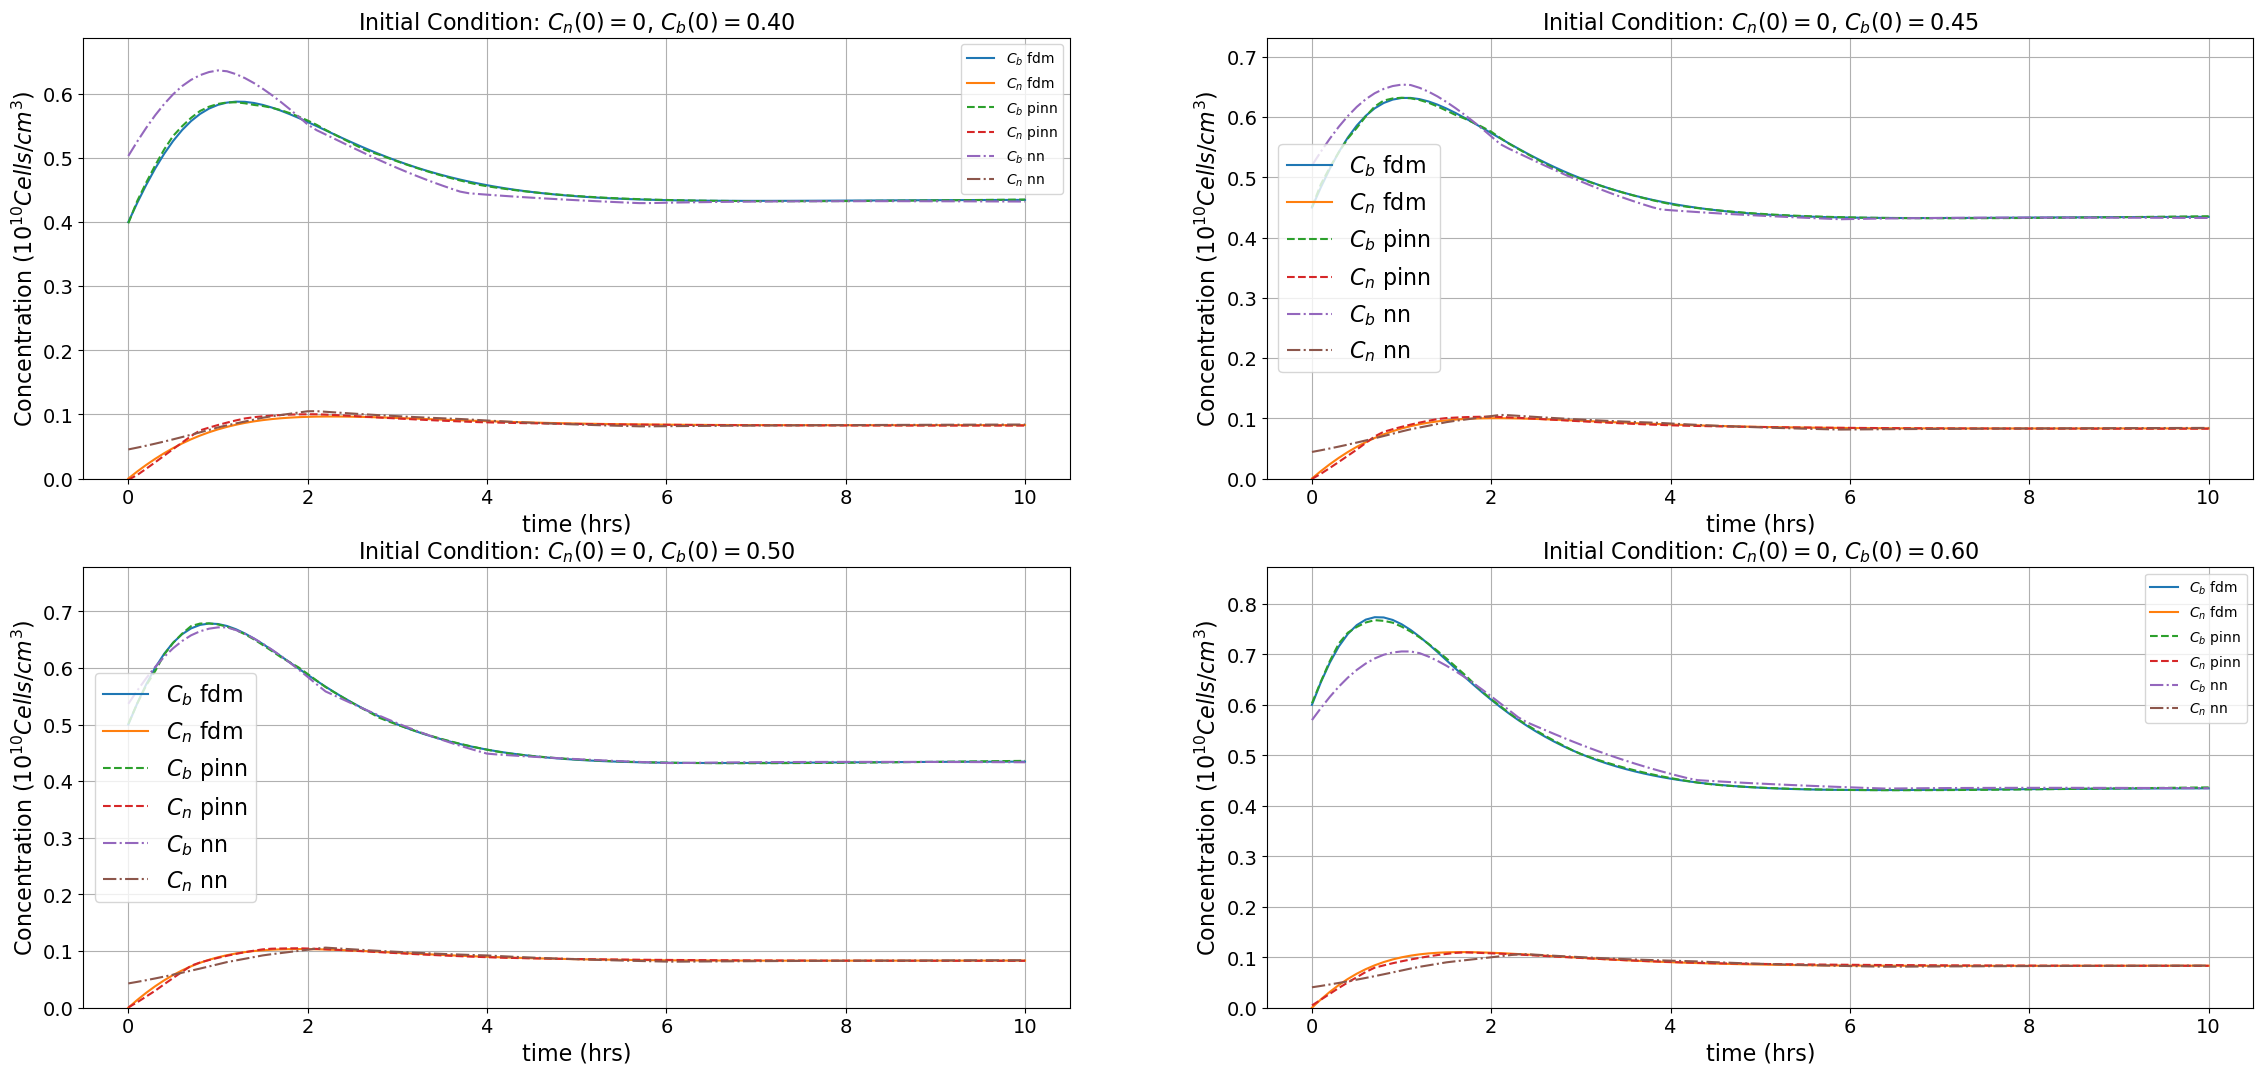

In [32]:
scale_factor = 1.4

fig = plt.figure(figsize=[20 * scale_factor, 9 * scale_factor])

# fig.suptitle("Concentração de patógenos e leucócitos", fontsize=16)


vmin = 0

cp_real_1 = Cp[0, :]
cl_real_1 = Cl[0, :]
cp_pinn_1 = Cp_pinn_np[0, :]
cl_pinn_1 = Cl_pinn_np[0, :]
cp_nn_1 = Cp_nn_data[0, :]
cl_nn_1 = Cl_nn_data[0, :]
ini_1 = initial[0]

cp_real_2 = Cp[25, :]
cl_real_2 = Cl[25, :]
cp_pinn_2 = Cp_pinn_np[25, :]
cl_pinn_2 = Cl_pinn_np[25, :]
cp_nn_2 = Cp_nn_data[25, :]
cl_nn_2 = Cl_nn_data[25, :]
ini_2 = initial[25]

cp_real_3 = Cp[50, :]
cl_real_3 = Cl[50, :]
cp_pinn_3 = Cp_pinn_np[50, :]
cl_pinn_3 = Cl_pinn_np[50, :]
cp_nn_3 = Cp_nn_data[50, :]
cl_nn_3 = Cl_nn_data[50, :]
ini_3 = initial[50]


cp_real_4 = Cp[100, :]
cl_real_4 = Cl[100, :]
cp_pinn_4 = Cp_pinn_np[100, :]
cl_pinn_4 = Cl_pinn_np[100, :]
cp_nn_4 = Cp_nn_data[100, :]
cl_nn_4 = Cl_nn_data[100, :]
ini_4 = initial[100]

# Plotango 3D
ax = fig.add_subplot(2, 2, 1)
ax.set_title("Initial Condition: $C_n(0) = 0$, $C_b(0) = {:.2f}$".format(ini_1), fontsize=16)

ax.plot(t_np, cp_real_1, label="$C_b$ fdm")
ax.plot(t_np, cl_real_1, label="$C_n$ fdm")
ax.plot(t_np, cp_pinn_1, "--", label="$C_b$ pinn")
ax.plot(t_np, cl_pinn_1, "--", label="$C_n$ pinn")
ax.plot(t_np, cp_nn_1, "-.", label="$C_b$ nn")
ax.plot(t_np, cl_nn_1, "-.", label="$C_n$ nn")

ax.set_xlabel("time (hrs)", fontsize=16)
ax.set_ylabel("Concentration $(10^{10}Cells/cm^3)$", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

vmax = np.max(
    [
        np.max(cp_real_1),
        np.max(cl_real_1),
        np.max(cp_pinn_1),
        np.max(cl_pinn_1),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

ax = fig.add_subplot(2, 2, 2)
ax.set_title("Initial Condition: $C_n(0) = 0$, $C_b(0) = {:.2f}$".format(ini_2), fontsize=16)

ax.plot(t_np, cp_real_2, label="$C_b$ fdm")
ax.plot(t_np, cl_real_2, label="$C_n$ fdm")
ax.plot(t_np, cp_pinn_2, "--", label="$C_b$ pinn")
ax.plot(t_np, cl_pinn_2, "--", label="$C_n$ pinn")
ax.plot(t_np, cp_nn_2, "-.", label="$C_b$ nn")
ax.plot(t_np, cl_nn_2, "-.", label="$C_n$ nn")
ax.set_xlabel("time (hrs)", fontsize=16)
ax.set_ylabel("Concentration $(10^{10}Cells/cm^3)$", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

vmax = np.max(
    [
        np.max(cp_real_2),
        np.max(cl_real_2),
        np.max(cp_pinn_2),
        np.max(cl_pinn_2),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend(prop={'size': 16})
ax.grid()

ax = fig.add_subplot(2, 2, 3)
ax.set_title("Initial Condition: $C_n(0) = 0$, $C_b(0) = {:.2f}$".format(ini_3), fontsize=16)

ax.plot(t_np, cp_real_3, label="$C_b$ fdm")
ax.plot(t_np, cl_real_3, label="$C_n$ fdm")
ax.plot(t_np, cp_pinn_3, "--", label="$C_b$ pinn")
ax.plot(t_np, cl_pinn_3, "--", label="$C_n$ pinn")
ax.plot(t_np, cp_nn_3, "-.", label="$C_b$ nn")
ax.plot(t_np, cl_nn_3, "-.", label="$C_n$ nn")
ax.set_xlabel("time (hrs)", fontsize=16)
ax.set_ylabel("Concentration $(10^{10}Cells/cm^3)$", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

vmax = np.max(
    [
        np.max(cp_real_3),
        np.max(cl_real_3),
        np.max(cp_pinn_3),
        np.max(cl_pinn_3),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend(prop={'size': 16})
ax.grid()

ax = fig.add_subplot(2, 2, 4)
ax.set_title("Initial Condition: $C_n(0) = 0$, $C_b(0) = {:.2f}$".format(ini_4), fontsize=16)

ax.plot(t_np, cp_real_4, label="$C_b$ fdm")
ax.plot(t_np, cl_real_4, label="$C_n$ fdm")
ax.plot(t_np, cp_pinn_4, "--", label="$C_b$ pinn")
ax.plot(t_np, cl_pinn_4, "--", label="$C_n$ pinn")
ax.plot(t_np, cp_nn_4, "-.", label="$C_b$ nn")
ax.plot(t_np, cl_nn_4, "-.", label="$C_n$ nn")
ax.set_xlabel("time (hrs)", fontsize=16)
ax.set_ylabel("Concentration $(10^{10}Cells/cm^3)$", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

vmax = np.max(
    [
        np.max(cp_real_4),
        np.max(cl_real_4),
        np.max(cp_pinn_4),
        np.max(cl_pinn_4),
    ]
)
ax.set_ylim(vmin, vmax + 0.1)
ax.legend()
ax.grid()

plt.show()

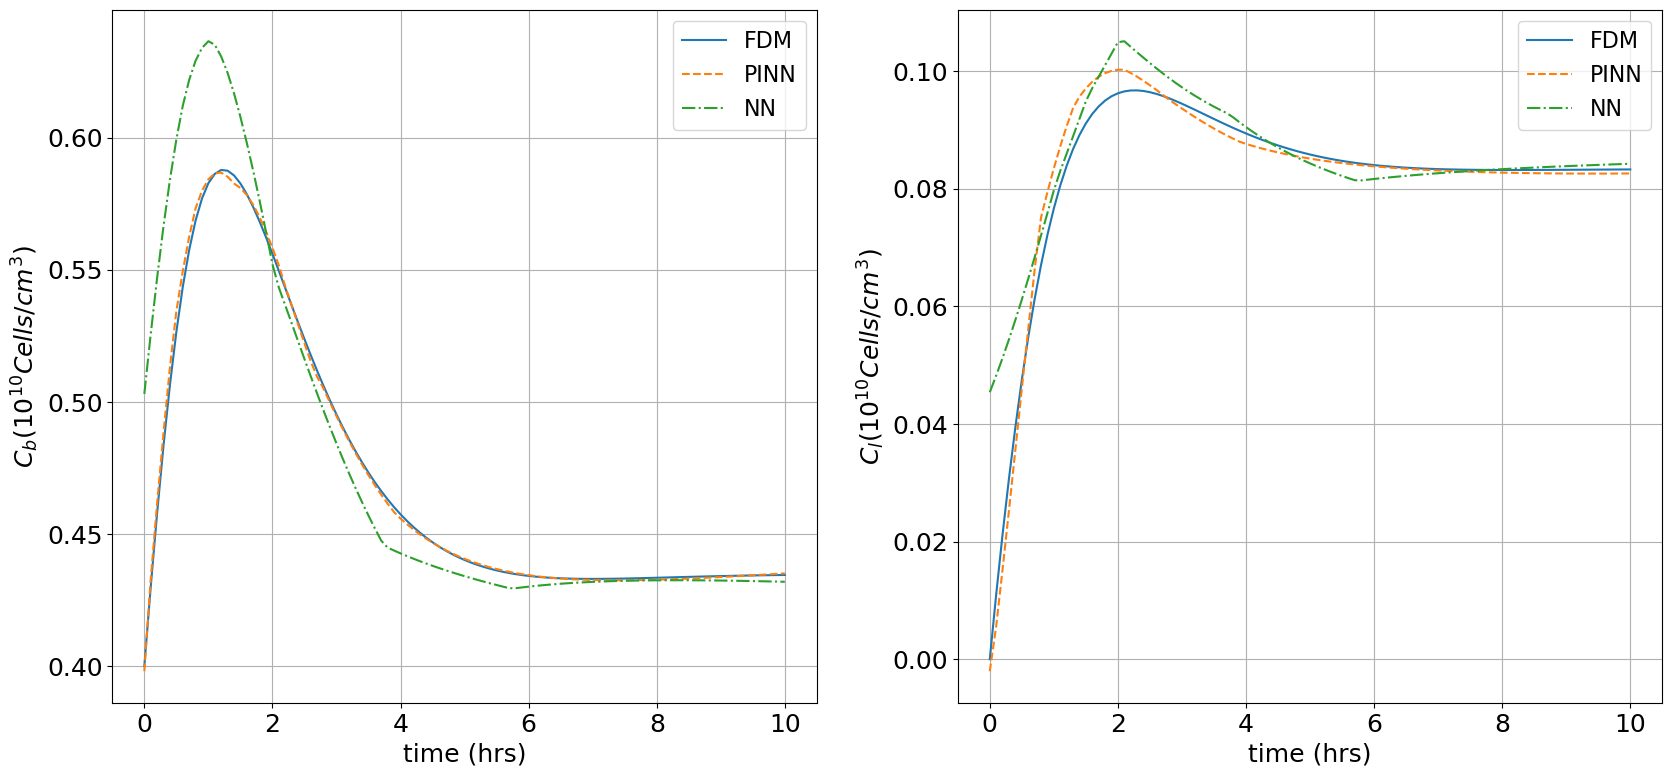

In [33]:
scale_factor = 1

fig = plt.figure(figsize=[20 * scale_factor, 9 * scale_factor])

# fig.suptitle("Concentração de patógenos e leucócitos", fontsize=18)


vmin = 0

cp_real_1 = Cp[0, :]
cl_real_1 = Cl[0, :]
cp_pinn_1 = Cp_pinn_np[0, :]
cl_pinn_1 = Cl_pinn_np[0, :]
cp_nn_1 = Cp_nn_data[0, :]
cl_nn_1 = Cl_nn_data[0, :]
ini_1 = initial[0]

# Plotango 3D
ax = fig.add_subplot(1, 2, 1)
# ax.set_title("$C_b$ for $C_b(0) = {:.2f}$".format(ini_1), fontsize=18)

ax.plot(t_np, cp_real_1, label="FDM")
ax.plot(t_np, cp_pinn_1, "--", label="PINN")
ax.plot(t_np, cp_nn_1, "-.", label="NN")

ax.set_xlabel("time (hrs)", fontsize=18)
ax.set_ylabel("$C_b(10^{10}Cells/cm^3)$", fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)


ax.legend(prop={'size': 16})
ax.grid()

ax = fig.add_subplot(1, 2, 2)
# ax.set_title("$C_n$ for $C_b(0) = {:.2f}$".format(ini_1), fontsize=18)


ax.plot(t_np, cl_real_1, label="FDM")
ax.plot(t_np, cl_pinn_1, "--", label="PINN")
ax.plot(t_np, cl_nn_1, "-.", label="NN")


ax.set_xlabel("time (hrs)", fontsize=18)
ax.set_ylabel("$C_l(10^{10}Cells/cm^3)$", fontsize=18)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

ax.legend(prop={'size': 16})
ax.grid()



plt.show()

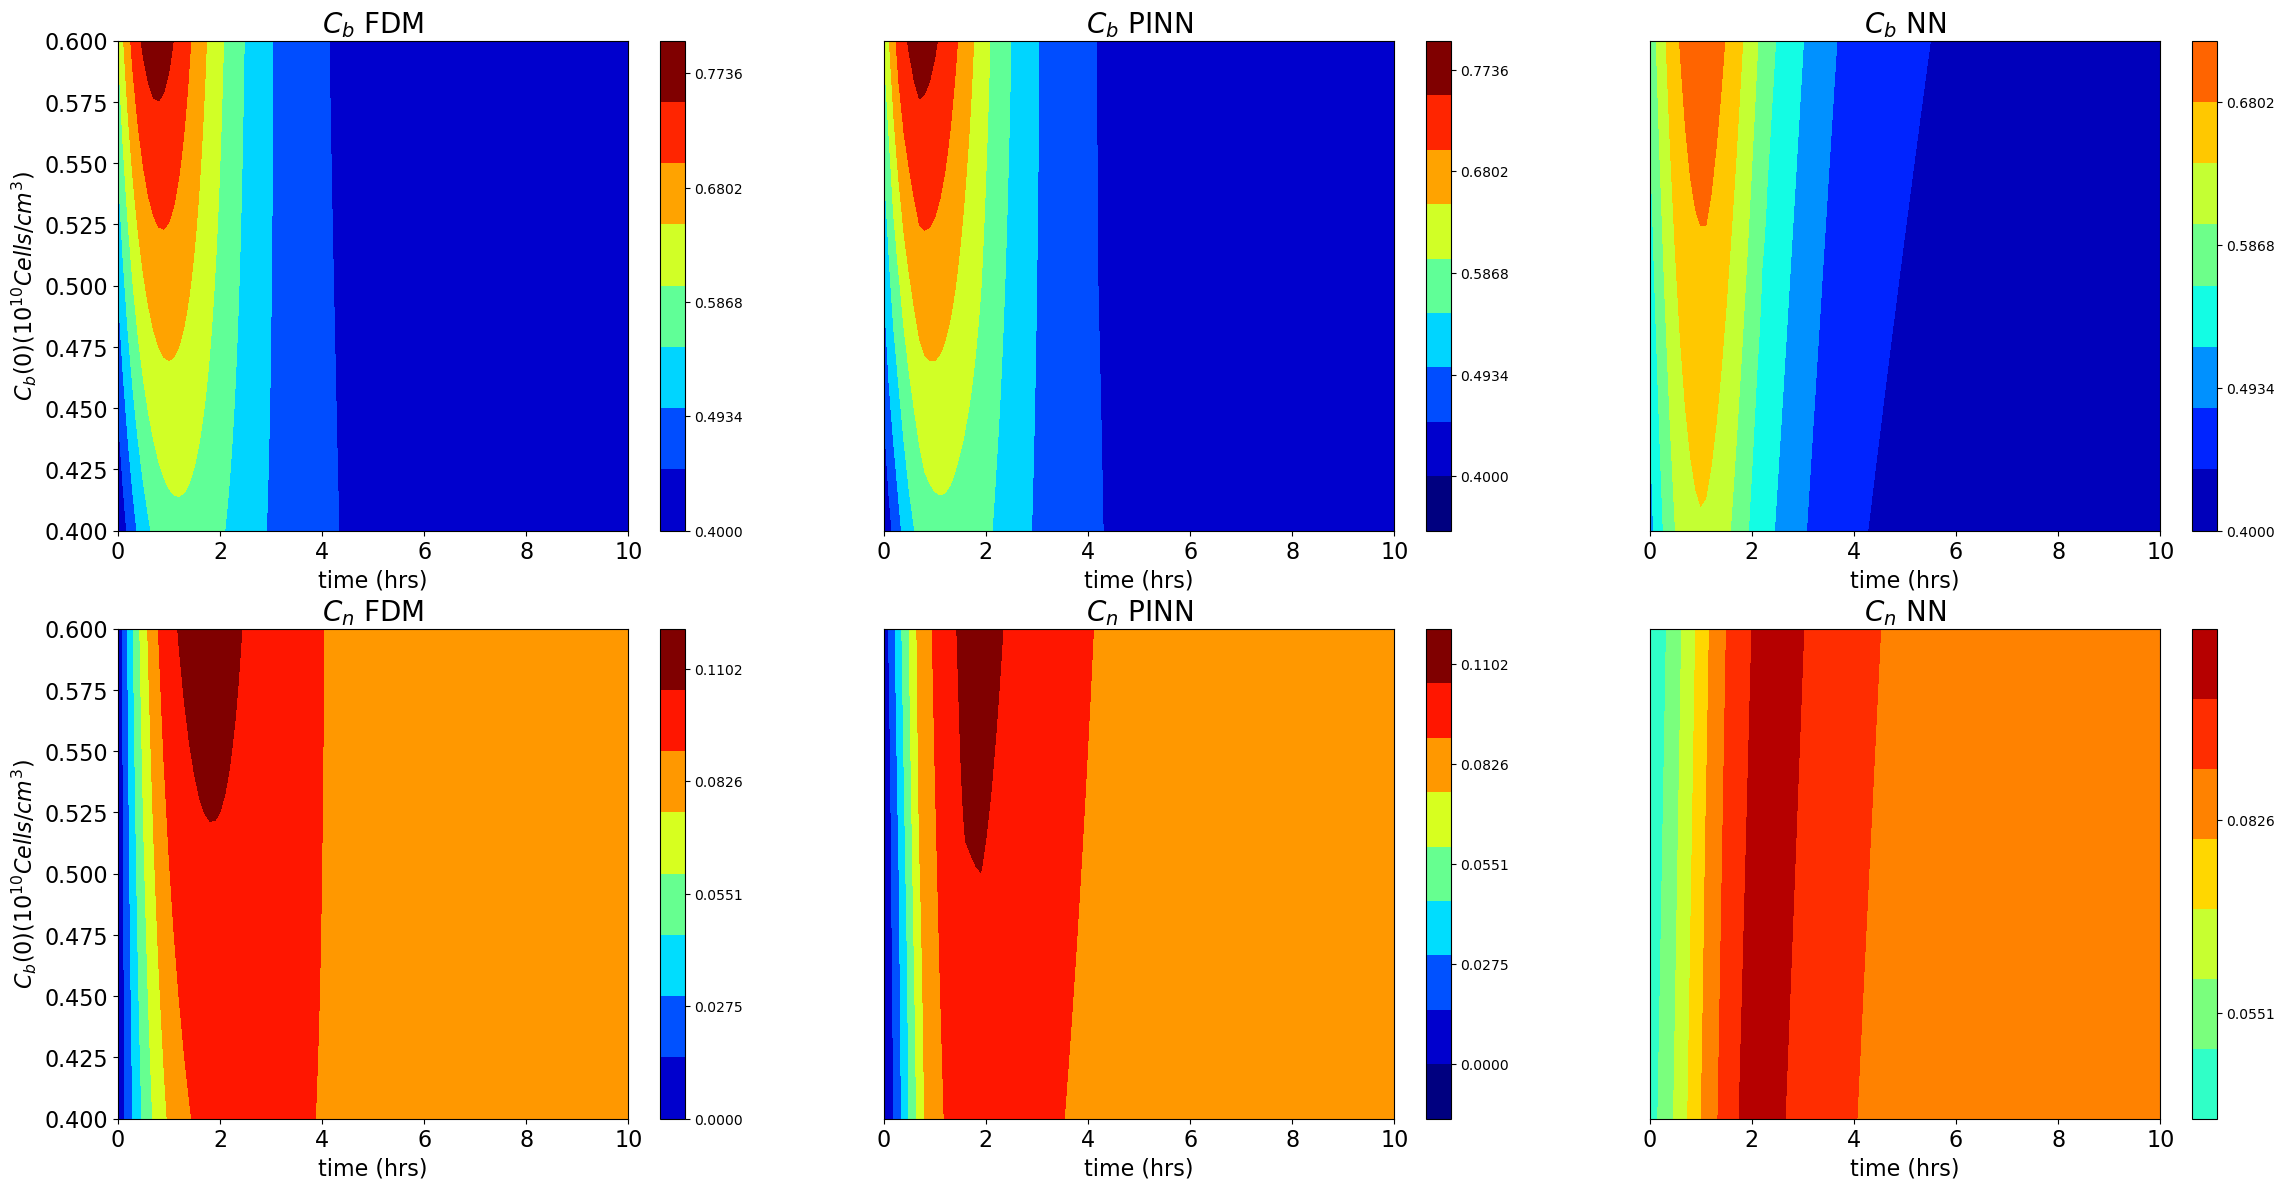

In [43]:
scale_factor = 1.4
fig = plt.figure(figsize=[20*scale_factor, 10*scale_factor])

# fig.suptitle("Imune system response", fontsize=20)


ax = fig.add_subplot(2, 3, 1)

vmin = np.min(Cp)
vmax = np.max(Cp)

contour = ax.contourf(
    tt,
    ii,
    Cp.reshape(size_t + 1, size_t + 1),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_b$ FDM", fontsize=20)
ax.set_xlabel("time (hrs)", fontsize=16)
ax.set_ylabel("$C_b(0) (10^{10}Cells/cm^3)$", fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

ax = fig.add_subplot(2, 3, 2)

# vmin = np.min(Cp_pinn_np)
# vmax = np.max(Cp_pinn_np)

contour = ax.contourf(
    tt,
    ii,
    Cp_pinn_np,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_b$ PINN", fontsize=20)
ax.set_xlabel("time (hrs)", fontsize=16)

plt.xticks(fontsize=16)
ax.get_yaxis().set_visible(False)

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

ax = fig.add_subplot(2, 3, 3)

# vmin = np.min(Cp_nn_data)
# vmax = np.max(Cp_nn_data)

contour = ax.contourf(
    tt,
    ii,
    Cp_nn_data,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_b$ NN", fontsize=20)
ax.set_xlabel("time (hrs)", fontsize=16)

plt.xticks(fontsize=16)
ax.get_yaxis().set_visible(False)

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

ax = fig.add_subplot(2, 3, 4)

vmin = np.min(Cl)
vmax = np.max(Cl)

contour = ax.contourf(
    tt,
    ii,
    Cl.reshape(size_t + 1, size_t + 1),
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_n$ FDM", fontsize=20)
ax.set_xlabel("time (hrs)", fontsize=16)
ax.set_ylabel("$C_b(0) (10^{10}Cells/cm^3)$", fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

ax = fig.add_subplot(2, 3, 5)

# vmin = np.min(Cl_pinn_np)
# vmax = np.max(Cl_pinn_np)

contour = ax.contourf(
    tt,
    ii,
    Cl_pinn_np,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_n$ PINN", fontsize=20)
ax.set_xlabel("time (hrs)", fontsize=16)

plt.xticks(fontsize=16)
ax.get_yaxis().set_visible(False)

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

ax = fig.add_subplot(2, 3, 6)

# vmin = np.min(Cl_nn_data)
# vmax = np.max(Cl_nn_data)

contour = ax.contourf(
    tt,
    ii,
    Cl_nn_data,
    cmap="jet",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("$C_n$ NN", fontsize=20)
ax.set_xlabel("time (hrs)", fontsize=16)
ax.set_ylabel("$C_b(0) (10^{10}Cells/cm^3)$", fontsize=16)

plt.xticks(fontsize=16)
ax.get_yaxis().set_visible(False)

colobar = fig.colorbar(contour, ticks=np.linspace(vmin, vmax, num=5))

plt.show()